# **Báo cáo Giữa kỳ (Midterm Project) - Môn: Data Mining**
**Đề tài: Predicting Flight Delays (Dự đoán thời gian trễ chuyến bay)**

**Nhóm sinh viên thực hiện:**
1. Nguyễn Thái Khánh Nam - 523H0159
2. Trần Văn Quí - 523H0174
3. Lê Khắc Thanh Trí - 523H0186

**Đánh giá:** 30% Midterm (Group presentation + Demo: DM problems and Algorithms)

___

## 1. Giới thiệu (Introduction)

Trong project này, nhóm chúng em sẽ xây dựng một mô hình máy học nhằm mục đích dự đoán thời gian trễ của các chuyến bay khi cất cánh. Thay vì chỉ tập trung vào việc tinh chỉnh để đạt được độ chính xác dự đoán cao nhất, mục tiêu cốt lõi của báo cáo là minh họa và giải thích chi tiết các bước cần thiết trong quy trình Khai phá Dữ liệu (Data Mining) để giải quyết một bài toán thực tế.

Thông qua quá trình thực hiện, nhóm sẽ làm rõ một số khái niệm **cơ bản nhưng rất quan trọng** trong các thuật toán Data Mining. Cụ thể, báo cáo sẽ đề cập đến tầm quan trọng của việc chia tách tập dữ liệu (train/test split) trong giai đoạn huấn luyện, và cách kỹ thuật **cross-validation** (kiểm tra chéo) giúp xác định các siêu tham số (hyperparameters) chính xác cho mô hình. Nhóm cũng sẽ demo cách xây dựng các thuật toán **tuyến tính (linear)** và **đa thức (polynomial)** cho bài toán **hồi quy đơn biến (univariate)** cũng như **đa biến (multivariate)**. Cuối cùng, nhóm sẽ trình bày một số phân tích về lý do tại sao kỹ thuật **điều chuẩn (regularization)** lại giúp các thuật toán của chúng ta tổng quát hóa (generalize) tốt hơn đối với dữ liệu chưa từng thấy.

____
## 2. Công nghệ và Thư viện sử dụng (Technical Stack)
Dưới góc độ kỹ thuật, các công cụ và thư viện Python chính được nhóm áp dụng xuyên suốt project bao gồm:
- **Trực quan hóa dữ liệu (Visualization)**: `matplotlib`, `seaborn`, `basemap`
- **Thao tác và tiền xử lý dữ liệu (Data manipulation)**: `pandas`, `numpy`
- **Xây dựng thuật toán Data Mining (Modeling)**: `scikit-learn` (sklearn), `scipy`
- **Lập trình cấu trúc (Class definition)**: Viết các class riêng biệt để đóng gói mô hình hồi quy và hàm vẽ đồ thị.

Trong giai đoạn Khám phá Dữ liệu (EDA - Exploratory Data Analysis), nhóm hướng tới việc tạo ra các biểu đồ trực quan, chất lượng cao để thông tin có thể được nắm bắt dễ dàng ngay từ cái nhìn đầu tiên. Một khía cạnh quan trọng khi làm Data Mining là khả năng diễn giải các phát hiện (insights) cho cả những người không có nền tảng chuyên sâu về kỹ thuật, do đó, việc làm chủ các công cụ visualization là một phần nhóm rất chú trọng trong demo này.

Ngoài ra, thay vì sao chép code nhiều lần (copy-paste), nhóm đã tối ưu mã nguồn bằng cách định nghĩa các Lớp (classes) và Hàm (functions) cho các thao tác lặp lại. Cách tiếp cận này giúp mã nguồn dễ đọc hơn, giảm thiểu số dòng code và hạn chế rủi ro phát sinh lỗi. Nhóm đã tự định nghĩa các class trong phần Modeling để tối ưu vòng lặp huấn luyện các thuật toán hồi quy, cũng như duy trì tính đồng nhất về mặt thẩm mỹ cho các biểu đồ trong toàn bộ báo cáo.

___
**Lời cảm ơn**: Báo cáo có tham khảo bộ khung sườn và phương pháp tiếp cận từ tác giả Fabien Daniel và J. Abécassis trên nền tảng Kaggle.
___

## 3. Cấu trúc của Project (Project Structure)

Project được cấu trúc thành ba giai đoạn chính chuẩn theo pipeline của Data Mining: Tiền xử lý (Phần 1), Khám phá dữ liệu EDA (Phần 2-5) và Xây dựng Thuật toán (Phần 6).

**_Mở đầu_:** _Tổng quan về tập dữ liệu (Dataset Overview)_ <br>

**1. Tiền xử lý và Làm sạch dữ liệu (Data Cleaning)**
- 1.1 Xử lý kiểu dữ liệu Ngày và Giờ (Dates and times)
- 1.2 Xử lý dữ liệu khuyết thiếu (Filling factor / Missing values handling)

**2. Phân tích và So sánh các hãng hàng không (Comparing airlines)**
- 2.1 Thống kê mô tả cơ bản
- 2.2 Phân phối độ trễ: Xếp hạng các hãng hàng không

**3. Phân tích độ trễ: Cất cánh hay Hạ cánh? (Delays: take-off or landing?)** <br>
**4. Mối liên hệ giữa sân bay xuất phát và độ trễ (Origin airport impact)** <br>
- 4.1 Phạm vi không gian địa lý của các hãng hàng không  <br>
- 4.2 Sân bay xuất phát ảnh hưởng đến độ trễ như thế nào <br>
- 4.3 Đặc điểm của các chuyến bay thường xuyên bị trễ? <br>

**5. Sự biến động của độ trễ theo thời gian (Temporal variability)** <br>

**6. Demo: Thuật toán Dự đoán thời gian trễ (DM Algorithms)** <br>
- 6.1 Mô hình nº1: Một hãng hàng không, một sân bay (Dữ liệu cục bộ)
  * 6.1.1 Những rủi ro có thể gặp phải (Pitfalls)
  * 6.1.2 Bậc của đa thức: Kỹ thuật chia tách tập dữ liệu
  * 6.1.3 Đánh giá mô hình: Dự đoán thời gian trễ cuối tháng 1
- 6.2 Mô hình nº2: Một hãng hàng không, tất cả các sân bay (Mở rộng không gian)
  * 6.2.1 Hồi quy tuyến tính (Linear regression)  
  * 6.2.2 Hồi quy đa thức (Polynomial regression)
  * 6.2.3 Tinh chỉnh tham số (Hyperparameter tuning)
  * 6.2.4 Đánh giá mô hình
- 6.3 Mô hình nº3: Tính toán bao gồm cả điểm đến (Phức tạp hóa đặc trưng)
   * 6.3.1 Lựa chọn các tham số tự do
   * 6.3.2 Đánh giá mô hình
   
**Kết luận (Conclusion)**

___
## _Mở đầu_: Tổng quan về tập dữ liệu (Dataset Overview)

Trước tiên, nhóm sẽ tiến hành khai báo và nạp (import) các thư viện phân tích dữ liệu, trực quan hoá và thuật toán học máy cần thiết để phục vụ cho việc thực thi code trong project này:

In [ ]:
!pip install basemap

In [ ]:
import datetime, warnings, scipy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pyproj
from matplotlib.patches import ConnectionPatch
from collections import OrderedDict
from matplotlib.gridspec import GridSpec
from mpl_toolkits.basemap import Basemap
from sklearn import metrics, linear_model
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from scipy.optimize import curve_fit
plt.rcParams["patch.force_edgecolor"] = True
plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor = 'dimgray', linewidth=1)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"
pd.options.display.max_columns = 50
%matplotlib inline
warnings.filterwarnings("ignore")

Sau khi thiết lập môi trường, nhóm tiến hành đọc tập dữ liệu chính (`flights.csv`), chứa thông tin chi tiết về các chuyến bay được ghi nhận trong năm 2015.

Để bước đầu đánh giá chất lượng của dữ liệu (Data Quality Assessment), nhóm trích xuất các thông tin nền tảng về cấu trúc của Dataframe, bao gồm kiểu dữ liệu của từng đặc trưng (features) và thống kê tỷ lệ dữ liệu bị khuyết thiếu (null values / missing data) cho từng cột:

In [ ]:
from google.colab import drive
import pandas as pd

# 1. Kết nối Colab với Google Drive (sẽ hiện popup yêu cầu bạn cấp quyền)
drive.mount('/content/drive')

# 2. Đường dẫn đến file zip trên Drive của bạn
# (Nếu bạn để trong một thư mục khác, hãy sửa lại đường dẫn này)
file_path = '/content/drive/MyDrive/flights.csv.zip'

# Đọc trực tiếp dữ liệu không cần giải nén thủ công
df = pd.read_csv(file_path, compression='zip', low_memory=False)

print('Dataframe dimensions:', df.shape)
print('_'*60)

# 3. Tạo bảng thông tin xử lý missing values
type_df = pd.DataFrame(df.dtypes).T.rename(index={0: 'column type'})
null_nb_df = pd.DataFrame(df.isnull().sum()).T.rename(index={0: 'null values (nb)'})
null_pct_df = pd.DataFrame(df.isnull().sum()/df.shape[0]*100).T.rename(index={0: 'null values (%)'})

tab_info = pd.concat([type_df, null_nb_df, null_pct_df])
tab_info

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataframe dimensions: (5819079, 31)
____________________________________________________________


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
column type,int64,int64,int64,int64,object,int64,object,object,object,int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,object,float64,float64,float64,float64,float64
null values (nb),0,0,0,0,0,0,14721,0,0,0,86153,86153,89047,89047,6,105071,105071,0,92513,92513,0,92513,105071,0,0,5729195,4755640,4755640,4755640,4755640,4755640
null values (%),0.0,0.0,0.0,0.0,0.0,0.0,0.252978,0.0,0.0,0.0,1.480526,1.480526,1.530259,1.530259,0.000103,1.805629,1.805629,0.0,1.589822,1.589822,0.0,1.589822,1.805629,0.0,0.0,98.455357,81.72496,81.72496,81.72496,81.72496,81.72496


Mỗi dòng (entry) trong tập dữ liệu `flights.csv` đại diện cho một chuyến bay. Có thể thấy Dataframe sở hữu dung lượng khá lớn với hơn 5.800.000 chuyến bay được ghi nhận trong năm 2015. Các chuyến bay này được cấu thành từ 31 biến (variables/features). Chi tiết từ điển dữ liệu (Data Dictionary) có thể tra cứu tại kho dữ liệu của Bộ GTVT Hoa Kỳ.

Dưới đây, nhóm tóm tắt lại ý nghĩa của các thuộc tính cốt lõi sẽ được sử dụng cho việc phân tích và huấn luyện mô hình:

- **YEAR, MONTH, DAY, DAY_OF_WEEK**: Các biến thời gian của chuyến bay. <br/>
- **AIRLINE**: Mã định danh (ID) dành riêng cho từng hãng hàng không. <br/>
- **ORIGIN_AIRPORT** và **DESTINATION_AIRPORT**: Mã IATA nhận diện sân bay khởi hành và sân bay đến. <br/>
- **SCHEDULED_DEPARTURE** và **SCHEDULED_ARRIVAL**: Thời gian cất cánh và hạ cánh theo lịch trình (lý thuyết). <br/>
- **DEPARTURE_TIME** và **ARRIVAL_TIME**: Thời gian cất cánh và hạ cánh thực tế. <br/>
- **DEPARTURE_DELAY** và **ARRIVAL_DELAY**: Độ chênh lệch (tính bằng phút) giữa thời gian thực tế và lịch trình. **Đây là các biến mục tiêu (target variables) mà thuật toán cần dự đoán.** <br/>
- **DISTANCE**: Khoảng cách chuyến bay (dặm - miles). <br/>

Bên cạnh đó, nhóm sử dụng thêm tập dữ liệu phụ `airports.csv` đóng vai trò như một bảng tra cứu (lookup table) để cung cấp thông tin không gian chi tiết hơn về các sân bay:

In [ ]:
airports = pd.read_csv("/content/drive/MyDrive/airports.csv")

Để có cái nhìn tổng quan (overview) về độ phủ không gian địa lý của tập dữ liệu này, nhóm sẽ áp dụng thư viện `basemap` để biểu diễn tọa độ các sân bay lên bản đồ nước Mỹ, đồng thời trực quan hóa mật độ chuyến bay được ghi nhận tại từng trạm trong năm 2015:

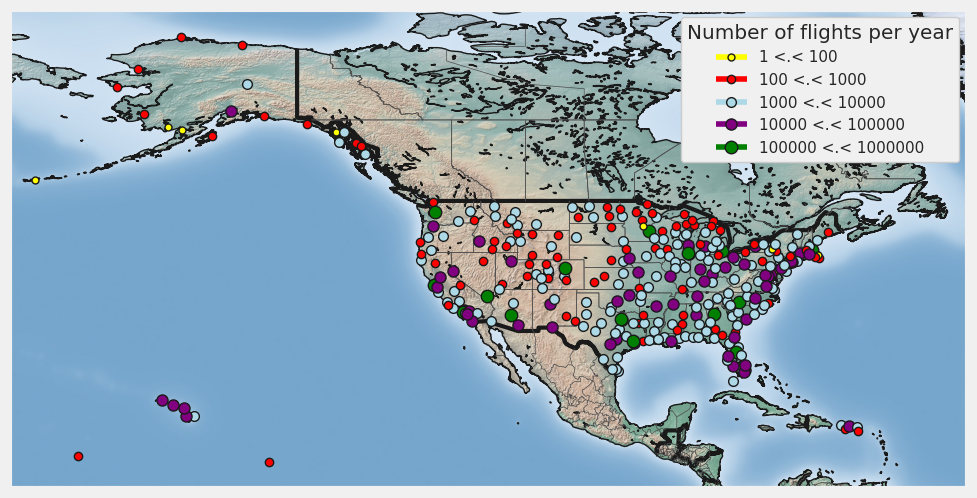

In [ ]:
count_flights = df['ORIGIN_AIRPORT'].value_counts()
plt.figure(figsize=(11,11))

colors = ['yellow', 'red', 'lightblue', 'purple', 'green', 'orange']
size_limits = [1, 100, 1000, 10000, 100000, 1000000]
labels = []
for i in range(len(size_limits)-1):
    labels.append("{} <.< {}".format(size_limits[i], size_limits[i+1]))

map = Basemap(resolution='i',llcrnrlon=-180, urcrnrlon=-50,
              llcrnrlat=10, urcrnrlat=75, lat_0=0, lon_0=0,)
map.shadedrelief()
map.drawcoastlines()
map.drawcountries(linewidth = 3)
map.drawstates(color='0.3')

for index, (code, y,x) in airports[['IATA_CODE', 'LATITUDE', 'LONGITUDE']].iterrows():
    x, y = map(x, y)
    isize = [i for i, val in enumerate(size_limits) if val < count_flights[code]]
    ind = isize[-1]
    map.plot(x, y, marker='o', markersize = ind+5, markeredgewidth = 1, color = colors[ind],
             markeredgecolor='k', label = labels[ind])

handles, labels = plt.gca().get_legend_handles_labels()
by_label = OrderedDict(zip(labels, handles))
key_order = ('1 <.< 100', '100 <.< 1000', '1000 <.< 10000',
             '10000 <.< 100000', '100000 <.< 1000000')
new_label = OrderedDict()
for key in key_order:
    new_label[key] = by_label[key]
plt.legend(new_label.values(), new_label.keys(), loc = 1, prop= {'size':11},
           title='Number of flights per year', frameon = True, framealpha = 1)
plt.show()

Với kích thước lớn của bộ dữ liệu, nhóm quyết định chỉ xem xét một tập con của dữ liệu để giảm thời gian xử lý. Nhóm sẽ chỉ giữ các chuyến bay từ tháng 1 năm 2015:

In [ ]:
df = df[df['MONTH'] == 1]

___
## 1. Làm sạch
___
### 1.1 Ngày và giờ

Trong dataframe ban đầu, ngày được mã hóa theo 4 biến: **YEAR, MONTH, DAY**, và **DAY_OF_WEEK**. Thực ra, Python cung cấp định dạng **_datetime_** rất tiện lợi để làm việc với ngày và giờ và do đó nhóm chuyển đổi ngày sang định dạng này:

In [ ]:
df['DATE'] = pd.to_datetime(df[['YEAR','MONTH', 'DAY']])

Hơn nữa, trong biến **SCHEDULED_DEPARTURE**, giờ cất cánh được mã hóa dưới dạng số thực, trong đó hai chữ số đầu tiên chỉ giờ và hai chữ số cuối chỉ phút. Định dạng này không thuận tiện và do đó nhóm chuyển đổi nó. Cuối cùng, nhóm kết hợp giờ cất cánh với ngày bay. Để thực hiện các chuyển đổi này, tôi định nghĩa một vài hàm:

In [ ]:
def format_heure(chaine):
    if pd.isnull(chaine):
        return np.nan
    else:
        if chaine == 2400: chaine = 0
        chaine = "{0:04d}".format(int(chaine))
        heure = datetime.time(int(chaine[0:2]), int(chaine[2:4]))
        return heure

def combine_date_heure(x):
    if pd.isnull(x[0]) or pd.isnull(x[1]):
        return np.nan
    else:
        return datetime.datetime.combine(x[0],x[1])

def create_flight_time(df, col):
    liste = []
    for index, cols in df[['DATE', col]].iterrows():
        if pd.isnull(cols[1]):
            liste.append(np.nan)
        elif float(cols[1]) == 2400:
            cols[0] += datetime.timedelta(days=1)
            cols[1] = datetime.time(0,0)
            liste.append(combine_date_heure(cols))
        else:
            cols[1] = format_heure(cols[1])
            liste.append(combine_date_heure(cols))
    return pd.Series(liste)

và nhóm gọi chúng để sửa đổi các biến trong dataframe:

In [ ]:
df['SCHEDULED_DEPARTURE'] = create_flight_time(df, 'SCHEDULED_DEPARTURE')
df['DEPARTURE_TIME'] = df['DEPARTURE_TIME'].apply(format_heure)
df['SCHEDULED_ARRIVAL'] = df['SCHEDULED_ARRIVAL'].apply(format_heure)
df['ARRIVAL_TIME'] = df['ARRIVAL_TIME'].apply(format_heure)

df.loc[:5, ['SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'DEPARTURE_TIME',
             'ARRIVAL_TIME', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY']]

,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,DEPARTURE_TIME,ARRIVAL_TIME,DEPARTURE_DELAY,ARRIVAL_DELAY
0,2015-01-01 00:05:00,04:30:00,23:54:00,04:08:00,-11.0,-22.0
1,2015-01-01 00:10:00,07:50:00,00:02:00,07:41:00,-8.0,-9.0
2,2015-01-01 00:20:00,08:06:00,00:18:00,08:11:00,-2.0,5.0
3,2015-01-01 00:20:00,08:05:00,00:15:00,07:56:00,-5.0,-9.0
4,2015-01-01 00:25:00,03:20:00,00:24:00,02:59:00,-1.0,-21.0
5,2015-01-01 00:25:00,06:02:00,00:20:00,06:10:00,-5.0,8.0


Lưu ý rằng trong thực tế, nội dung của các biến **DEPARTURE_TIME** và **ARRIVAL_TIME** có thể gây hiểu nhầm một chút vì chúng không chứa ngày tháng. Ví dụ, trong mục nhập đầu tiên của dataframe, chuyến bay dự kiến khởi hành vào lúc 0h05 ngày 1 tháng 1. Biến **DEPARTURE_TIME** chỉ ra 23h54 và do đó chúng ta không biết liệu chuyến bay đã xuất phát sớm hay có sự chậm trễ lớn. Do đó, các biến **DEPARTURE_DELAY** và **ARRIVAL_DELAY** sẽ hữu ích hơn vì chúng cung cấp trực tiếp độ trễ theo phút. Vì vậy, trong phần sau, nhóm sẽ không sử dụng các biến **DEPARTURE_TIME** và **ARRIVAL_TIME**.

###1.2 Hệ số lấp đầy

Cuối cùng, nhóm dọn dẹp dataframe bằng cách loại bỏ các biến tôi sẽ không sử dụng và sắp xếp lại các cột để dễ đọc hơn:

In [ ]:
variables_to_remove = ['TAXI_OUT', 'TAXI_IN', 'WHEELS_ON', 'WHEELS_OFF', 'YEAR',
                       'MONTH','DAY','DAY_OF_WEEK','DATE', 'AIR_SYSTEM_DELAY',
                       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
                       'WEATHER_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
                       'FLIGHT_NUMBER', 'TAIL_NUMBER', 'AIR_TIME']
df.drop(variables_to_remove, axis = 1, inplace = True)
df = df[['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
        'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY',
        'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
        'SCHEDULED_TIME', 'ELAPSED_TIME']]
df[:5]

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,SCHEDULED_TIME,ELAPSED_TIME
0,AS,ANC,SEA,2015-01-01 00:05:00,23:54:00,-11.0,04:30:00,04:08:00,-22.0,205.0,194.0
1,AA,LAX,PBI,2015-01-01 00:10:00,00:02:00,-8.0,07:50:00,07:41:00,-9.0,280.0,279.0
2,US,SFO,CLT,2015-01-01 00:20:00,00:18:00,-2.0,08:06:00,08:11:00,5.0,286.0,293.0
3,AA,LAX,MIA,2015-01-01 00:20:00,00:15:00,-5.0,08:05:00,07:56:00,-9.0,285.0,281.0
4,AS,SEA,ANC,2015-01-01 00:25:00,00:24:00,-1.0,03:20:00,02:59:00,-21.0,235.0,215.0


Ở giai đoạn này, nhóm kiểm tra mức độ đầy đủ của bộ dữ liệu:

In [ ]:
missing_df = df.isnull().sum(axis=0).reset_index()
missing_df.columns = ['variable', 'missing values']
missing_df['filling factor (%)']=(df.shape[0]-missing_df['missing values'])/df.shape[0]*100
missing_df.sort_values('filling factor (%)').reset_index(drop = True)

,variable,missing values,filling factor (%)
0,ELAPSED_TIME,12955,97.243429
1,ARRIVAL_DELAY,12955,97.243429
2,ARRIVAL_TIME,12271,97.388971
3,DEPARTURE_TIME,11657,97.519618
4,DEPARTURE_DELAY,11657,97.519618
5,DESTINATION_AIRPORT,0,100.000000
6,SCHEDULED_DEPARTURE,0,100.000000
7,AIRLINE,0,100.000000
8,SCHEDULED_ARRIVAL,0,100.000000
9,ORIGIN_AIRPORT,0,100.000000


Chúng ta thấy rằng tỷ lệ lấp đầy của các biến khá tốt (> 97%). Vì phạm vi của công việc này không nhằm mục đích tạo ra một mô hình dự đoán trễ chuyến bay tiên tiến nhất (state-of-the-art), tôi quyết định tiếp tục mà không cố gắng điền khuyết các phần bị thiếu và tôi chỉ đơn giản là loại bỏ các bản ghi chứa giá trị bị khuyết.

In [ ]:
df.dropna(inplace = True)

___
## 2. So sánh các hãng hàng không

Như đã nói trước đó, biến **AIRLINE** chứa các chữ viết tắt của hãng hàng không. Tên đầy đủ của chúng có thể được lấy từ file `airlines.csv`.

In [ ]:
airlines_names = pd.read_csv('/content/drive/MyDrive/airlines.csv')
airlines_names

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


Để sử dụng tiếp, tôi đưa nội dung của dataframe này vào một dictionary:

In [ ]:
abbr_companies = airlines_names.set_index('IATA_CODE')['AIRLINE'].to_dict()

___
### 2.1 Mô tả thống kê cơ bản của các hãng hàng không

Là bước đầu tiên, nhóm xem xét tất cả các chuyến bay từ tất cả các hãng vận chuyển. Ở đây, mục đích là phân loại các hãng hàng không dựa trên mức độ đúng giờ của họ và cho mục đích đó, nhóm tính toán một vài thông số thống kê cơ bản:

Cụ thể, đối với mỗi hãng hàng không, các chỉ số này có ý nghĩa như sau:

- **Count** (Số lượng): Tổng số chuyến bay của hãng hàng không đó đã thực hiện (được ghi nhận trong tập dữ liệu). Ý nghĩa: Giúp nhóm đánh giá quy mô hoạt động của hãng (hãng bay nhiều hay bay ít).

- **Mean** (Trung bình): Thời gian trễ trung bình của tất cả các chuyến bay thuộc hãng đó. Ý nghĩa: Cho biết nhìn chung hãng này thường trễ bao nhiêu phút. (Nếu mean là số âm, tức là trung bình hãng đó thường khởi hành/hạ cánh sớm hơn lịch trình).

- **Min** (Giá trị nhỏ nhất): Thời gian trễ thấp nhất được ghi nhận của hãng. Ý nghĩa: Thường là một con số âm rất lớn, đại diện cho chuyến bay cất cánh/hạ cánh sớm nhất so với dự kiến.

- **Max** (Giá trị lớn nhất): Thời gian trễ cao nhất được ghi nhận của hãng. Ý nghĩa: Đại diện cho chuyến bay bị delay tồi tệ nhất (chậm trễ lâu nhất, có thể lên tới vài trăm hoặc hàng nghìn phút do bão hoặc sự cố kỹ thuật).

In [ ]:
def get_stats(group):
    return {'min': group.min(), 'max': group.max(),
            'count': group.count(), 'mean': group.mean()}

global_stats = df['DEPARTURE_DELAY'].groupby(df['AIRLINE']).apply(get_stats).unstack()
global_stats = global_stats.sort_values('count')
global_stats

,min,max,count,mean
AIRLINE,,,,
VX,-20.0,397.0,4647.0,6.896277
HA,-26.0,1003.0,6408.0,1.311954
F9,-32.0,696.0,6735.0,17.910765
NK,-28.0,557.0,8632.0,13.073100
AS,-47.0,444.0,13151.0,3.072086
B6,-27.0,500.0,20482.0,9.988331
MQ,-29.0,780.0,27568.0,15.995865
US,-26.0,638.0,32478.0,5.175011
UA,-40.0,886.0,37363.0,13.885555


Bây giờ, để thuận tiện cho việc thể hiện thông tin đó, nhóm xây dựng một số hình ảnh:

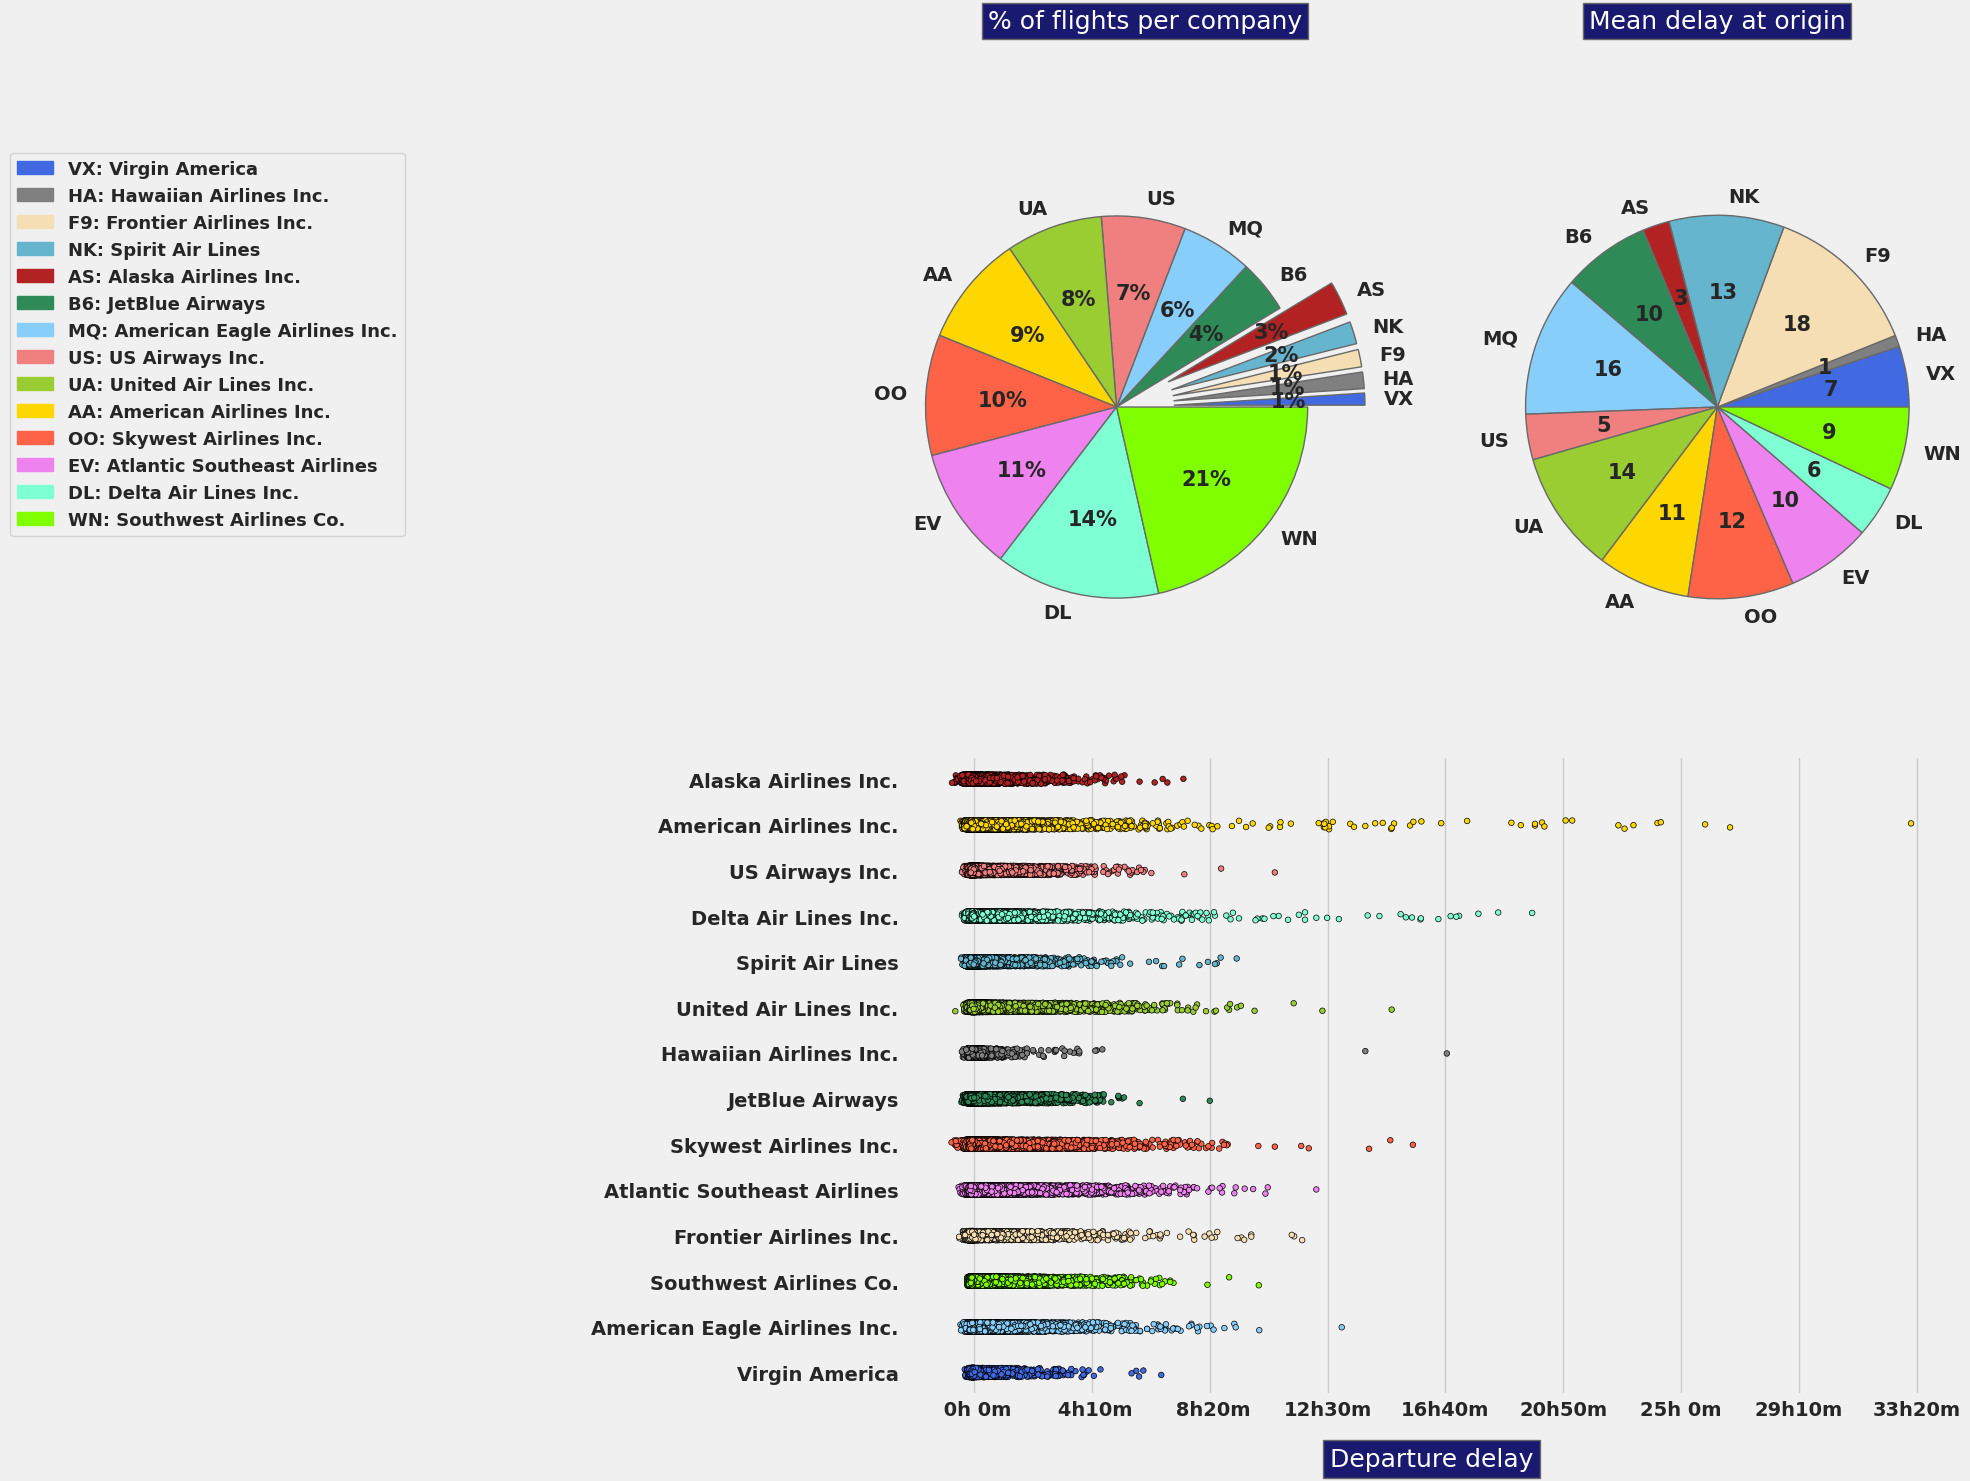

In [ ]:
font = {'family' : 'sans-serif', 'weight' : 'bold', 'size'   : 15}
mpl.rc('font', **font)
import matplotlib.patches as mpatches

df2 = df.loc[:, ['AIRLINE', 'DEPARTURE_DELAY']]
df2['AIRLINE'] = df2['AIRLINE'].replace(abbr_companies)
colors = ['royalblue', 'grey', 'wheat', 'c', 'firebrick', 'seagreen', 'lightskyblue',
          'lightcoral', 'yellowgreen', 'gold', 'tomato', 'violet', 'aquamarine', 'chartreuse']

fig = plt.figure(1, figsize=(16,15))
gs=GridSpec(2,2)
ax1=fig.add_subplot(gs[0,0])
ax2=fig.add_subplot(gs[0,1])
ax3=fig.add_subplot(gs[1,:])

labels = [s for s in  global_stats.index]
sizes  = global_stats['count'].values
explode = [0.3 if sizes[i] < 20000 else 0.0 for i in range(len(abbr_companies))]
patches, texts, autotexts = ax1.pie(sizes, explode = explode,
                                labels=labels, colors = colors,  autopct='%1.0f%%',
                                shadow=False, startangle=0)
for i in range(len(abbr_companies)):
    texts[i].set_fontsize(14)
ax1.axis('equal')
ax1.set_title('% of flights per company', bbox={'facecolor':'midnightblue', 'pad':5},
              color = 'w',fontsize=18, y=1.08)

comp_handler = []
for i in range(len(abbr_companies)):
    comp_handler.append(mpatches.Patch(color=colors[i],
            label = global_stats.index[i] + ': ' + abbr_companies[global_stats.index[i]]))
ax1.legend(handles=comp_handler, bbox_to_anchor=(0.02, 0.9),
           fontsize = 13, bbox_transform=plt.gcf().transFigure)

sizes  = global_stats['mean'].values
sizes  = [max(s,0) for s in sizes]
explode = [0.0 if sizes[i] < 20000 else 0.01 for i in range(len(abbr_companies))]
patches, texts, autotexts = ax2.pie(sizes, explode = explode, labels = labels,
                                colors = colors, shadow=False, startangle=0,
                                autopct = lambda p :  '{:.0f}'.format(p * sum(sizes) / 100))
for i in range(len(abbr_companies)):
    texts[i].set_fontsize(14)
ax2.axis('equal')
ax2.set_title('Mean delay at origin', bbox={'facecolor':'midnightblue', 'pad':5},
              color='w', fontsize=18,y=1.08)

colors = ['firebrick', 'gold', 'lightcoral', 'aquamarine', 'c', 'yellowgreen', 'grey',
          'seagreen', 'tomato', 'violet', 'wheat', 'chartreuse', 'lightskyblue', 'royalblue']

ax3 = sns.stripplot(y="AIRLINE", x="DEPARTURE_DELAY", size=4, palette=list(colors),
                    data=df2, jitter=True, hue="AIRLINE", legend=False)

plt.setp(ax3.collections, edgecolor='black', linewidth=0.5)
plt.setp(ax3.get_xticklabels(), fontsize=14)
plt.setp(ax3.get_yticklabels(), fontsize=14)
ax3.set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*[int(y) for y in divmod(x,60)])
                         for x in ax3.get_xticks()])
plt.xlabel('Departure delay', fontsize=18, bbox={'facecolor':'midnightblue', 'pad':5},
           color='w', labelpad=20)
ax3.yaxis.label.set_visible(False)

plt.tight_layout(w_pad=3)
plt.show()

Quan sát biểu đồ tròn đầu tiên thể hiện tỷ lệ phần trăm chuyến bay của từng hãng hàng không, nhóm nhận thấy có sự chênh lệch khá lớn về quy mô khai thác giữa các hãng. Ví dụ, riêng Southwest Airlines đã chiếm khoảng 20% tổng số chuyến bay, tương đương với tổng khối lượng chuyến bay của 7 hãng hàng không nhỏ nhất cộng lại. Tuy nhiên, khi chuyển sang phân tích biểu đồ tròn thứ hai (về độ trễ trung bình), bức tranh lại hoàn toàn trái ngược: sự khác biệt về độ trễ giữa các hãng là không quá rõ rệt. Nếu loại trừ Hawaiian Airlines và Alaska Airlines – hai hãng ghi nhận mức độ trễ trung bình cực kỳ thấp – nhóm nhận thấy mức $\sim$11 $\pm$ 7 phút là con số đại diện chính xác cho thời gian trễ trung bình của tất cả các hãng còn lại. Lưu ý rằng giá trị trung bình này khá thấp, cho thấy tiêu chuẩn vận hành chung của hầu hết các hãng hàng không vẫn là tuân thủ nghiêm ngặt lịch trình!

Cuối cùng, biểu đồ ở dưới cùng (đồ thị phân tán) đã tổng hợp toàn bộ các trường hợp bị trễ chuyến được đo lường trong tháng 1 năm 2015. Cách trực quan hóa này mang lại cái nhìn rõ nét về độ phân tán (dispersion) của dữ liệu, đồng thời làm rõ hơn tính đồng nhất tương đối đã xuất hiện ở biểu đồ tròn thứ hai. Thật vậy, mặc dù thời gian trễ trung bình chỉ xoay quanh mốc 10 phút, nhưng giá trị thấp này thực chất là hệ quả của việc đại đa số các chuyến bay đều cất cánh đúng giờ. Dù vậy, biểu đồ cũng chỉ ra một thực tế: thỉnh thoảng chúng ta vẫn bắt gặp các điểm dữ liệu ngoại lai (outliers) với độ trễ cực kỳ nghiêm trọng, có thể kéo dài đến vài chục giờ đồng hồ!

Tỷ trọng áp đảo của các chuyến bay bị trễ ngắn hạn sẽ được trực quan hóa chi tiết hơn trong biểu đồ tiếp theo:

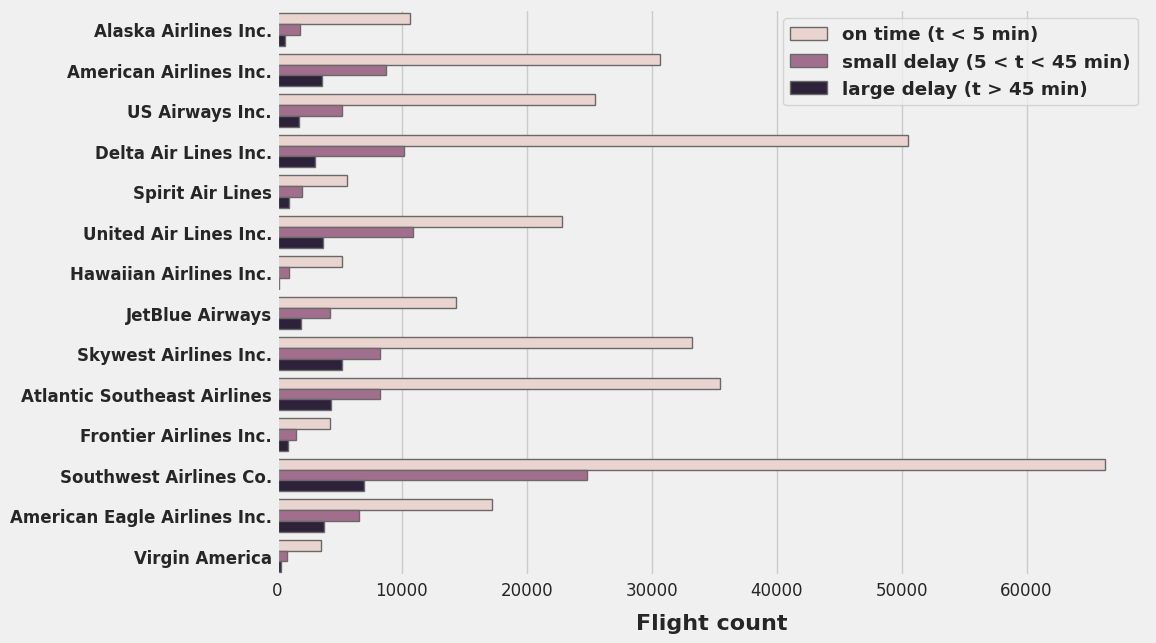

In [ ]:
delay_type = lambda x:((0,1)[x > 5],2)[x > 45]
df['DELAY_LEVEL'] = df['DEPARTURE_DELAY'].apply(delay_type)

fig = plt.figure(1, figsize=(10,7))
ax = sns.countplot(y="AIRLINE", hue='DELAY_LEVEL', data=df)

labels = [abbr_companies[item.get_text()] for item in ax.get_yticklabels()]
ax.set_yticklabels(labels)
plt.setp(ax.get_xticklabels(), fontsize=12, weight = 'normal', rotation = 0);
plt.setp(ax.get_yticklabels(), fontsize=12, weight = 'bold', rotation = 0);
ax.yaxis.label.set_visible(False)
plt.xlabel('Flight count', fontsize=16, weight = 'bold', labelpad=10)

L = plt.legend()
L.get_texts()[0].set_text('on time (t < 5 min)')
L.get_texts()[1].set_text('small delay (5 < t < 45 min)')
L.get_texts()[2].set_text('large delay (t > 45 min)')
plt.show()

Biểu đồ này thống kê số lượng các chuyến bay bị trễ theo ba mức độ: trễ dưới 5 phút, trễ trong khoảng từ 5 đến 45 phút (5 < t < 45 phút), và cuối cùng là trễ nghiêm trọng (hơn 45 phút). Qua quan sát, nhóm nhận thấy rằng dù xét ở bất kỳ hãng hàng không nào, các sự cố trễ chuyến kéo dài hơn 45 phút cũng chỉ chiếm một tỷ lệ rất nhỏ (khoảng vài phần trăm).

Tuy nhiên, tỷ trọng phân bổ giữa ba mức độ trễ này lại có sự biến động tùy thuộc vào từng hãng hàng không. Lấy ví dụ, trong trường hợp của SkyWest Airlines, số lượng chuyến bay bị trễ trên 45 phút chỉ thấp hơn khoảng $\sim$30% so với nhóm trễ trung bình (từ 5 đến 45 phút). Ngược lại, tình hình vận hành của Southwest Airlines lại khả quan hơn rất nhiều: tần suất xảy ra các ca trễ trên 45 phút thấp hơn đến 4 lần so với các ca trễ từ 5 đến 45 phút.

### 2.2 Phân phối độ trễ: Xây dựng bảng xếp hạng các hãng hàng không

Như đã trình bày ở phần trước, độ trễ trung bình giữa các hãng hàng không nhìn chung khá đồng đều (ngoại trừ hai trường hợp ngoại lệ) và dao động ở mức khoảng 11$\pm$7 phút. Nhóm cũng đã chỉ ra rằng mức trung bình thấp này thực chất là hệ quả từ việc có một tỷ lệ rất lớn các chuyến bay cất cánh đúng lịch trình. Tuy nhiên, thỉnh thoảng hệ thống vẫn ghi nhận những sự cố trễ chuyến kéo dài. Vì vậy, trong phần này, nhóm sẽ đi sâu vào phân tích chi tiết phân phối độ trễ (delays distribution) của từng hãng hàng không:

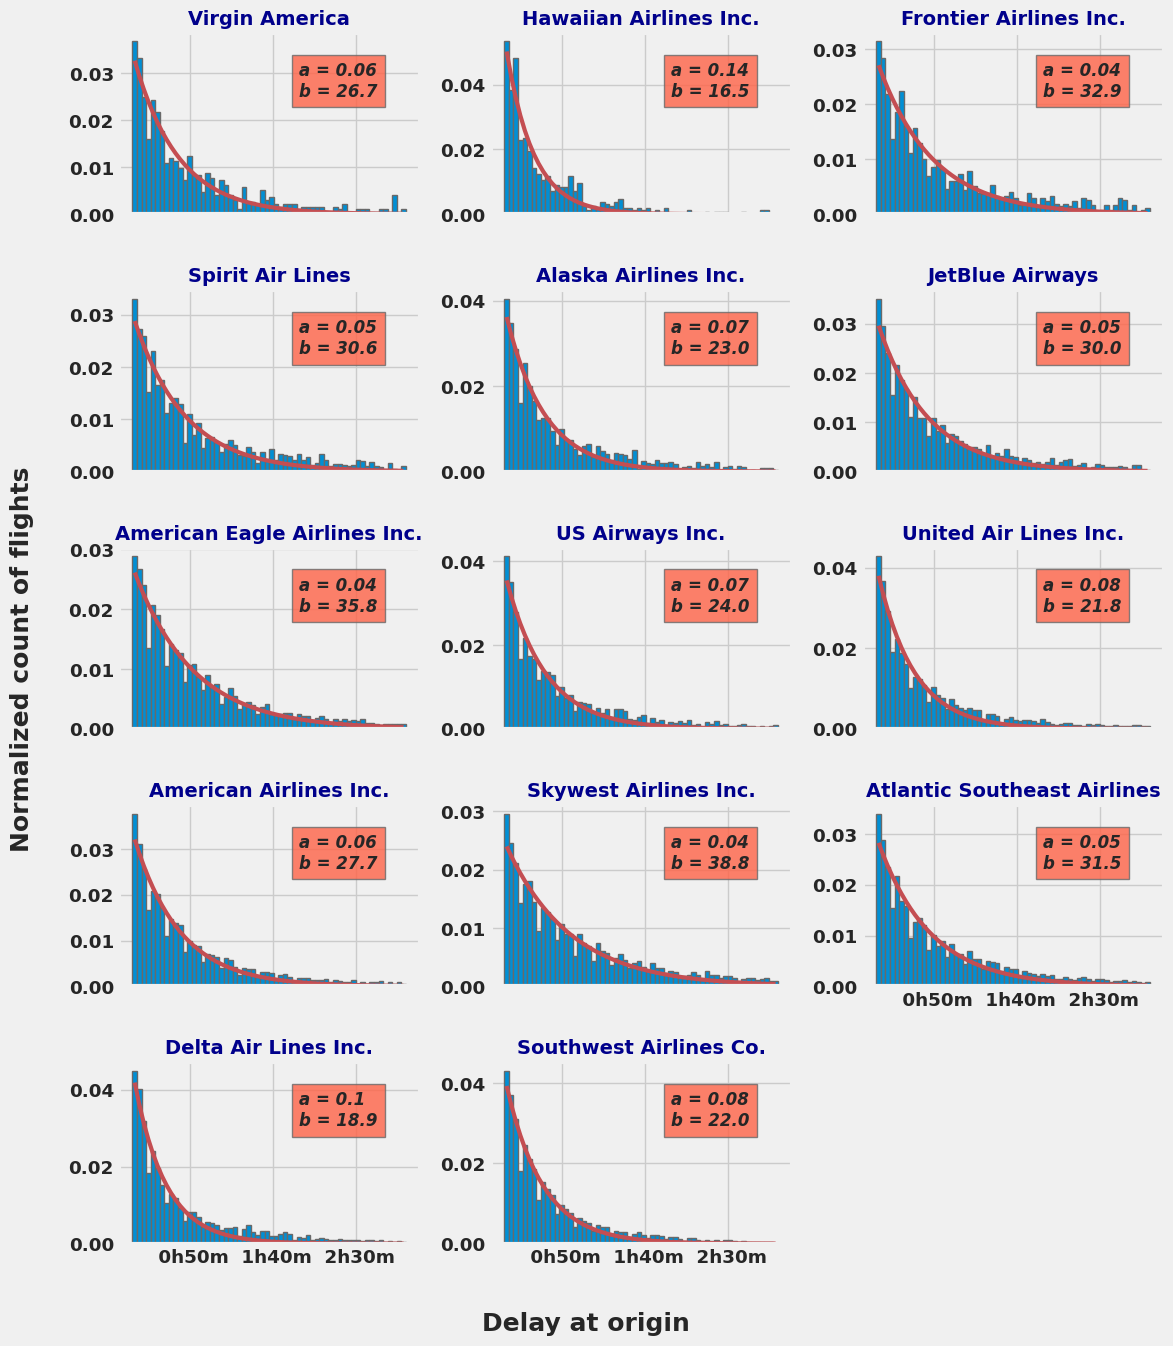

In [ ]:
from scipy.optimize import curve_fit

def func(x, a, b):
    return a * np.exp(-x/b)

points = [] ; label_company = []

fig = plt.figure(1, figsize=(12, 14))
i = 0

for carrier_name in [abbr_companies[x] for x in global_stats.index]:
    i += 1
    ax = fig.add_subplot(5, 3, i)

    n, bins, patches = plt.hist(x = df2[df2['AIRLINE']==carrier_name]['DEPARTURE_DELAY'],
                                range = (15,180), density=True, bins= 60)
    bin_centers = bins[:-1] + 0.5 * (bins[1:] - bins[:-1])
    popt, pcov = curve_fit(func, bin_centers, n, p0 = [1, 2])

    points.append(popt)
    label_company.append(carrier_name)

    plt.plot(bin_centers, func(bin_centers, *popt), 'r-', linewidth=3)

    if i not in [12, 13, 14]:
        ax.set_xticklabels(['' for x in ax.get_xticks()])
    else:
        ax.set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*[int(y) for y in divmod(x,60)])
                            for x in ax.get_xticks()])

    plt.title(carrier_name, fontsize = 14, fontweight = 'bold', color = 'darkblue')

    ax.text(0.60, 0.65, 'a = {}\nb = {}'.format(round(popt[0],2), round(popt[1],1)),
            style='italic', transform=ax.transAxes, fontsize = 12, family='sans-serif',
            bbox={'facecolor':'tomato', 'alpha':0.8, 'pad':5})

fig.text(0.02, 0.5, 'Normalized count of flights', va='center', rotation='vertical', fontsize=18)
fig.text(0.5, 0.02, 'Delay at origin', ha='center', fontsize=18)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.98], h_pad=2.0, w_pad=1.0)
plt.show()

Biểu đồ trên thể hiện phân phối chuẩn hóa của các khoảng thời gian trễ, được nhóm mô hình hóa bằng một hàm phân phối mũ có phương trình $f(x) = a \, \mathrm{exp} (-x/b)$. Các tham số $a$ và $b$ thu được dùng để mô tả từng hãng hàng không được hiển thị ở góc trên bên phải của mỗi đồ thị con (panel).

Cần lưu ý rằng việc chuẩn hóa phân phối ngụ ý giá trị tích phân $\int f(x) \, dx \sim 1$. Ở đây, chúng ta không có một đẳng thức tuyệt đối (dấu bằng =) vì phép chuẩn hóa được áp dụng trên các biểu đồ tần suất (histogram) chứ không áp dụng trực tiếp lên hàm mô hình. Tuy nhiên, mối liên hệ này dẫn đến việc hai hệ số $a$ và $b$ sẽ có sự tương quan tỷ lệ nghịch với nhau ($a \propto 1/b$). Do đó, trên thực tế, chúng ta chỉ cần dùng một trong hai giá trị này là đã đủ để diễn tả toàn bộ hình dáng của các phân phối.

Cuối cùng, dựa vào giá trị của $a$ hoặc $b$, nhóm hoàn toàn có thể thiết lập một bảng xếp hạng cho các hãng hàng không: những giá trị $a$ thấp sẽ đại diện cho các hãng có tỷ lệ trễ chuyến kéo dài (nghiêm trọng) cao. Ngược lại, những hãng hàng không nổi bật về sự đúng giờ và độ tin cậy sẽ đạt được giá trị $a$ cao:

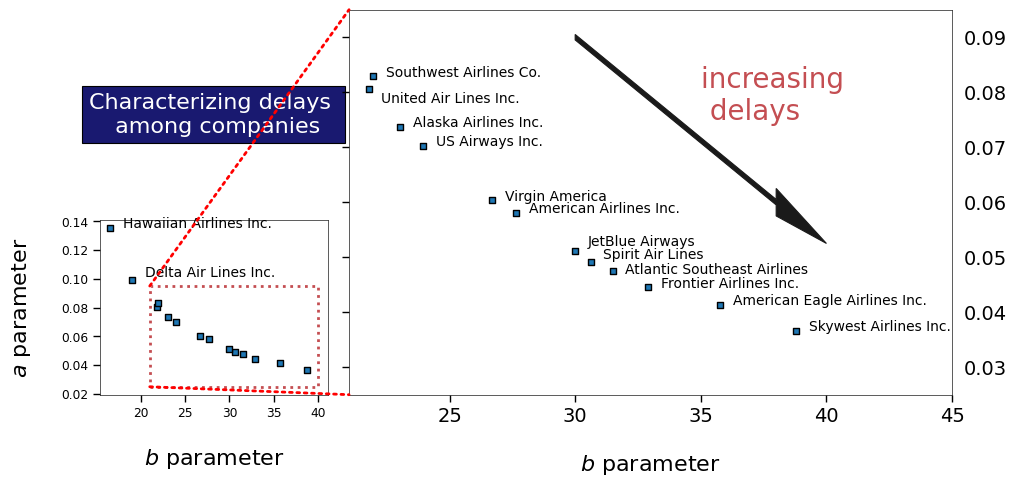

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch, Rectangle
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(mpl.rcParamsDefault)
sns.set_context('paper')

fig = plt.figure(1, figsize=(11,5))

y_shift = [0 for _ in range(14)]
y_shift[3] = 0.5/1000
y_shift[12] = 2.5/1000
y_shift[11] = -0.5/1000
y_shift[8] = -2.5/1000
y_shift[5] = 1/1000

x_val = [s[1] for s in points]
y_val = [s[0] for s in points]

gs = GridSpec(2, 7)

ax1 = fig.add_subplot(gs[1, 0:2])
ax1.scatter(x=x_val, y=y_val, marker='s', edgecolor='black', linewidth=1)

for i in [1, 12]:
    ax1.annotate(label_company[i], xy=(x_val[i]+1.5, y_val[i]+y_shift[i]),
                 xycoords='data', fontsize=10)

ax1.set_xlabel("$b$ parameter", fontsize=16, labelpad=20)
ax1.set_ylabel("$a$ parameter", fontsize=16, labelpad=20)

ax1.text(.5, 1.5, 'Characterizing delays \n among companies', fontsize=16,
         bbox={'facecolor': 'midnightblue', 'pad': 5}, color='w',
         horizontalalignment='center', transform=ax1.transAxes)

for k in ['top', 'bottom', 'right', 'left']:
    ax1.spines[k].set_visible(True)
    ax1.spines[k].set_linewidth(0.5)
    ax1.spines[k].set_color('k')

rect = Rectangle((21, 0.025), 19, 0.07, linewidth=2,
                 edgecolor='r', linestyle=':', facecolor='none')
ax1.add_patch(rect)

ax2 = fig.add_subplot(gs[0:2, 2:])
ax2.scatter(x=x_val, y=y_val, marker='s', edgecolor='black', linewidth=1)

ax2.set_xlim(21, 45)
ax2.set_ylim(0.025, 0.095)

for i in range(len(label_company)):
    ax2.annotate(label_company[i], xy=(x_val[i]+0.5, y_val[i]+y_shift[i]),
                 xycoords='data', fontsize=10)

ax2.arrow(30, 0.09, 8, -0.03, head_width=0.005,
          shape='full', head_length=2, fc='k', ec='k')
ax2.annotate('increasing \n delays', fontsize=20, color='r',
             xy=(35, 0.075), xycoords='data')

ax2.tick_params(labelleft=False, labelright=True)
plt.setp(ax2.get_xticklabels(), fontsize=14)
plt.setp(ax2.get_yticklabels(), fontsize=14)
ax2.set_xlabel("$b$ parameter", fontsize=16, labelpad=20)

for k in ['top', 'bottom', 'right', 'left']:
    ax2.spines[k].set_visible(True)
    ax2.spines[k].set_linewidth(0.5)
    ax2.spines[k].set_color('k')

con1 = ConnectionPatch(xyA=(21, 0.095), xyB=(21, 0.095), coordsA="data", coordsB="data",
                      axesA=ax1, axesB=ax2, linestyle=':', linewidth=2, color="red")
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(21, 0.025), xyB=(21, 0.025), coordsA="data", coordsB="data",
                      axesA=ax1, axesB=ax2, linestyle=':', linewidth=2, color="red")
fig.add_artist(con2)

plt.show()

Biểu đồ bên trái của hình này cung cấp cái nhìn tổng quan về các hệ số $a$ và $b$ của 14 hãng hàng không, qua đó cho thấy Hawaiian Airlines và Delta Airlines là hai cái tên lần lượt chiếm giữ các vị trí dẫn đầu (về độ đúng giờ). Biểu đồ bên phải thực hiện thao tác thu phóng (zoom) để quan sát kỹ hơn 12 hãng hàng không còn lại. Nhóm nhận thấy rằng Southwest Airlines, mặc dù chiếm tới $\sim$20% tổng số lượng chuyến bay, vẫn có thứ hạng rất tốt và giữ vị trí thứ ba trong bảng xếp hạng. Ngược lại, dựa trên tiêu chí đánh giá này, SkyWest Airlines được xác định là hãng hàng không có hiệu suất vận hành thấp nhất.

___
## 3. Trì hoãn: cất cánh hay hạ cánh?
Trong phần trước, tất cả các thảo luận và số liệu của nhóm đều liên quan đến sự chậm trễ khi khởi hành. Tuy nhiên, những sự chậm trễ này có phần khác so với những chậm trễ được ghi nhận khi đến nơi:

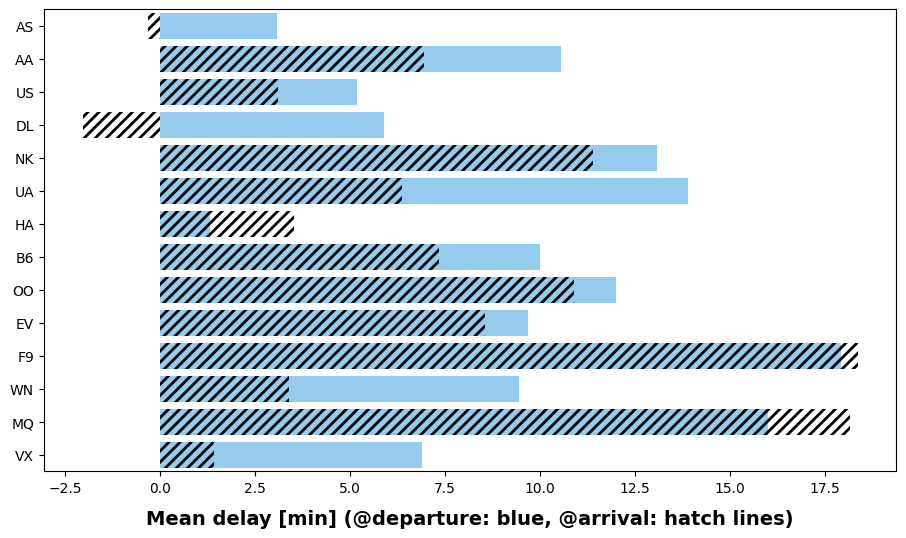

In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['hatch.linewidth'] = 2.0

fig = plt.figure(1, figsize=(11,6))

ax = sns.barplot(x="DEPARTURE_DELAY", y="AIRLINE", data=df, color="lightskyblue", errorbar=None)

ax = sns.barplot(x="ARRIVAL_DELAY", y="AIRLINE", data=df, color="r", hatch = '///',
                 alpha = 0.0, errorbar=None)

ax.yaxis.label.set_visible(False)
plt.xlabel('Mean delay [min] (@departure: blue, @arrival: hatch lines)',
           fontsize=14, weight = 'bold', labelpad=10)

plt.show()

Quan sát biểu đồ trên, nhóm nhận thấy rằng độ trễ khi hạ cánh (arrival delays) nhìn chung thường thấp hơn so với độ trễ khi cất cánh (departure delays). Điều này cho thấy các hãng hàng không đã chủ động điều chỉnh tốc độ bay trong suốt hành trình nhằm bù đắp thời gian và giảm thiểu sự chậm trễ khi đến điểm đích. Trong các nội dung tiếp theo của báo cáo, nhóm sẽ tập trung phân tích dựa trên biến độ trễ cất cánh; tuy nhiên, chúng ta cần lưu ý rằng thông số này có thể có những sai khác nhất định so với độ trễ thực tế tại thời điểm hạ cánh.

___
## 4. Mối liên hệ giữa sân bay xuất phát và tình trạng trễ chuyến (Relation between the origin airport and delays)

Trong phần này, nhóm sẽ tiến hành phân tích để xác định xem liệu có mối tương quan nào giữa thời gian trễ chuyến được ghi nhận và sân bay xuất phát (airport of origin) hay không. Theo thống kê từ tập dữ liệu, tổng số sân bay được đưa vào xem xét là:

In [ ]:
print("Nb of airports: {}".format(len(df['ORIGIN_AIRPORT'].unique())))

Nb of airports: 312


---
### 4.1 Phạm vi địa lý của các hãng hàng không (Geographical area covered by airlines)
Trong phần này, nhóm sẽ thực hiện thống kê nhanh về số lượng các sân bay điểm đến (destination airports) mà mỗi hãng hàng không đang khai thác:

In [ ]:
origin_nb = dict()
for carrier in abbr_companies.keys():
    liste_origin_airport = df[df['AIRLINE'] == carrier]['ORIGIN_AIRPORT'].unique()
    origin_nb[carrier] = len(liste_origin_airport)

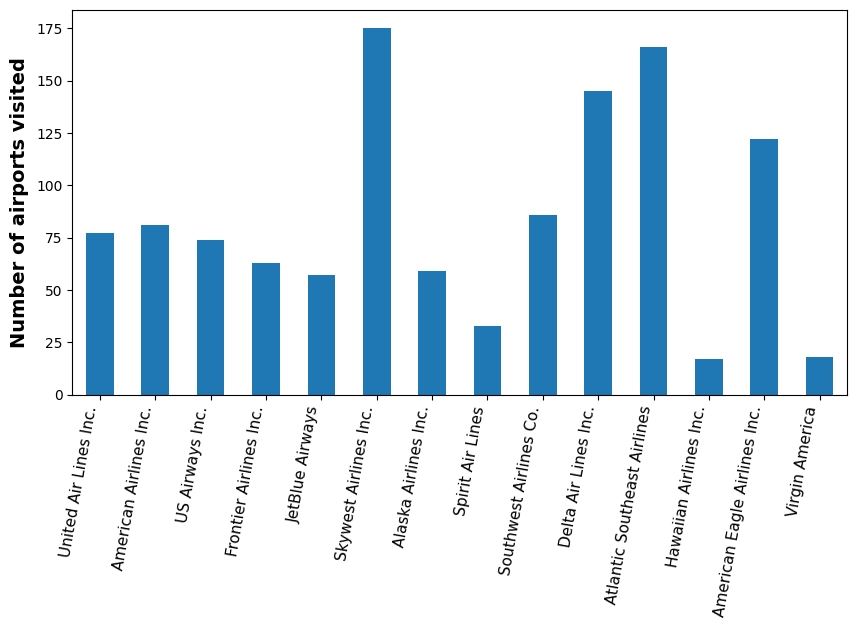

In [ ]:
test_df = pd.DataFrame.from_dict(origin_nb, orient='index')
test_df.rename(columns = {0:'count'}, inplace = True)
ax = test_df.plot(kind='bar', figsize = (10,5))
labels = [abbr_companies[item.get_text()] for item in ax.get_xticklabels()]
ax.set_xticklabels(labels)
plt.ylabel('Number of airports visited', fontsize=14, weight = 'bold', labelpad=12, va='center', ha='center')
plt.setp(ax.get_xticklabels(), fontsize=11, ha = 'right', rotation = 80)
ax.legend().set_visible(False)
plt.show()

In [ ]:
temp = pd.read_csv('/content/drive/MyDrive/airports.csv')
identify_airport = temp.set_index('IATA_CODE')['CITY'].to_dict()
latitude_airport = temp.set_index('IATA_CODE')['LATITUDE'].to_dict()
longitude_airport = temp.set_index('IATA_CODE')['LONGITUDE'].to_dict()

In [ ]:
from collections import OrderedDict
import numpy as np

def make_map(df, carrier, long_min, long_max, lat_min, lat_max):
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_axes([0., 0., 1., 1.])

    m = Basemap(resolution='i', llcrnrlon=long_min, urcrnrlon=long_max,
                llcrnrlat=lat_min, urcrnrlat=lat_max, lat_0=0, lon_0=0)

    df2 = df[df['AIRLINE'] == carrier]
    count_trajectories = df2.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).size()
    count_trajectories.sort_values(inplace=True)

    g = pyproj.Geod(ellps='WGS84')

    for (origin, dest), s in count_trajectories.items():
        nylat, nylon = latitude_airport[origin], longitude_airport[origin]
        if pd.isnull(nylat) or pd.isnull(nylon): continue
        m.plot(nylon, nylat, marker='o', markersize=8, markeredgewidth=1,
               color='seagreen', markeredgecolor='k', zorder=5)

    for (origin, dest), s in count_trajectories.items():
        nylat, nylon = latitude_airport[origin], longitude_airport[origin]
        lonlat, lonlon = latitude_airport[dest], longitude_airport[dest]

        if pd.isnull(nylat) or pd.isnull(nylon) or pd.isnull(lonlat) or pd.isnull(lonlon):
            continue

        path = g.npts(nylon, nylat, lonlon, lonlat, 100)

        path = [(nylon, nylat)] + path + [(lonlon, lonlat)]
        lons, lats = zip(*path)

        x, y = m(lons, lats)

        if s < 100:
            m.plot(x, y, linewidth=0.5, color='b', alpha=0.3, label='< 100')
        elif s < 200:
            m.plot(x, y, linewidth=1.5, color='r', alpha=0.5, label='100 <.< 200')
        else:
            m.plot(x, y, linewidth=2.5, color='gold', alpha=0.7, label='> 200')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    key_order = ('< 100', '100 <.< 200', '> 200')
    new_label = OrderedDict()
    for key in key_order:
        if key in by_label: new_label[key] = by_label[key]

    plt.legend(new_label.values(), new_label.keys(), loc='best', prop={'size': 10},
               title='flights per month', facecolor='palegreen', shadow=True)

    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='aqua')
    ax.set_title('{} flights'.format(abbr_companies[carrier]))
    plt.show()

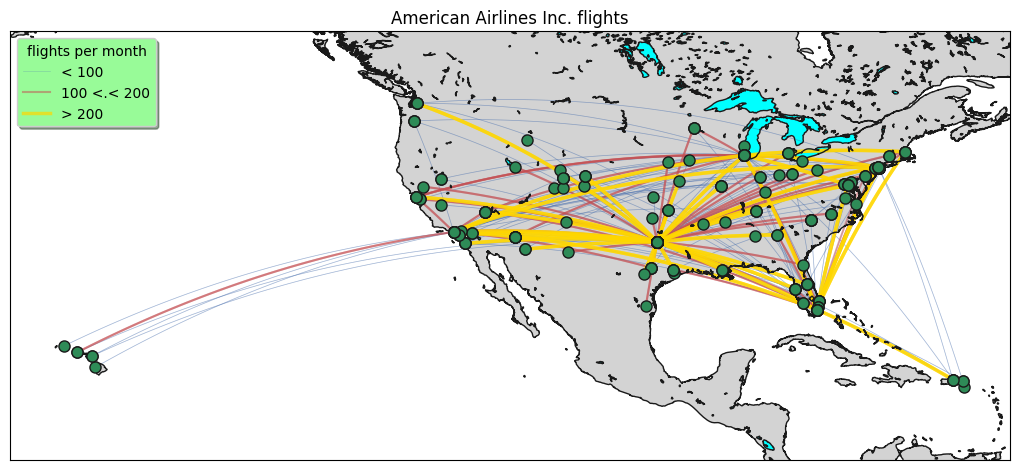

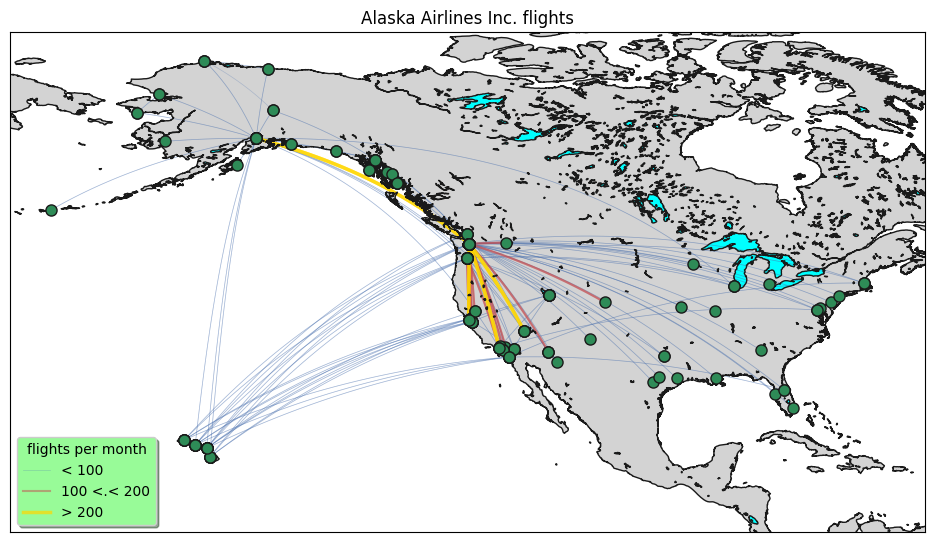

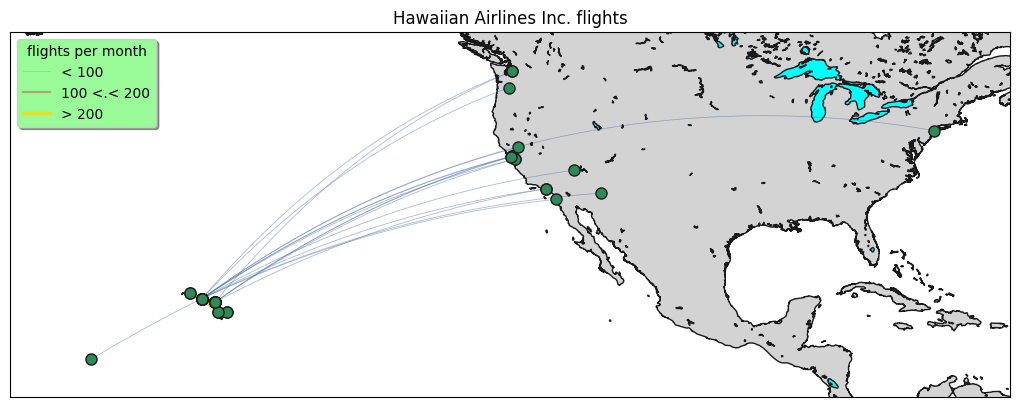

In [ ]:
coord = dict()
coord['AA'] = [-165, -60, 10, 55]
coord['AS'] = [-182, -63, 10, 75]
coord['HA'] = [-180, -65, 10, 52]
for carrier in ['AA', 'AS', 'HA']:
    make_map(df, carrier, *coord[carrier])

___
### 4.2 Sân bay xuất phát ảnh hưởng thế nào đến tình trạng trễ chuyến (How the origin airport impact delays)
Trong phần này, nhóm sẽ tiến hành phân tích sự biến thiên của các khoảng thời gian trễ chuyến dựa trên sân bay xuất phát đối với từng hãng hàng không cụ thể. Theo đó, bước đầu tiên cần thực hiện là xác định giá trị độ trễ trung bình (mean delays) tại mỗi sân bay:

In [ ]:
airport_mean_delays = pd.DataFrame(pd.Series(df['ORIGIN_AIRPORT'].unique()))
airport_mean_delays.set_index(0, drop = True, inplace = True)

for carrier in abbr_companies.keys():
    df1 = df[df['AIRLINE'] == carrier]
    test = df1['DEPARTURE_DELAY'].groupby(df['ORIGIN_AIRPORT']).apply(get_stats).unstack()
    airport_mean_delays[carrier] = test.loc[:, 'mean']

Vì số lượng sân bay trong tập dữ liệu là rất lớn, việc cố gắng hiển thị tất cả thông tin trên cùng một biểu đồ sẽ gây ra tình trạng quá tải và cực kỳ rối mắt, bởi khi đó biểu đồ sẽ phải biểu diễn tới khoảng $4400$ giá trị (tương đương với $312$ sân bay $\times$ $14$ hãng hàng không). Vì vậy, để đảm bảo tính trực quan và dễ theo dõi, nhóm quyết định chỉ trình bày một tập con (subset) tiêu biểu của dữ liệu:

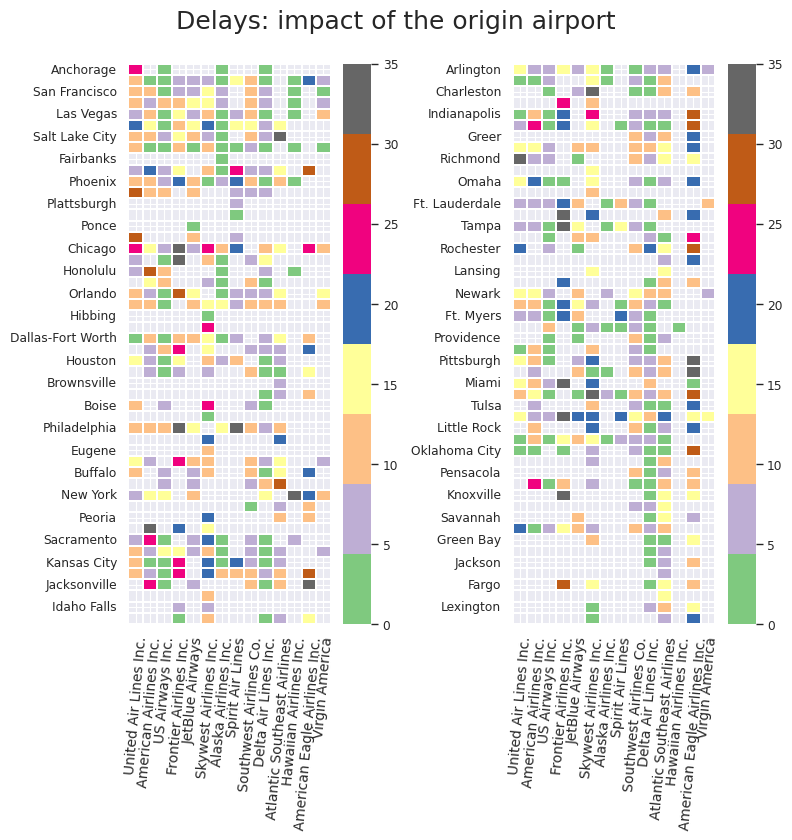

In [ ]:
sns.set(context="paper")
fig = plt.figure(1, figsize=(8,8))

ax = fig.add_subplot(1,2,1)
subset = airport_mean_delays.iloc[:50,:].rename(columns = abbr_companies)
subset = subset.rename(index = identify_airport)
mask = subset.isnull()
sns.heatmap(subset, linewidths=0.01, cmap="Accent", mask=mask, vmin = 0, vmax = 35)
plt.setp(ax.get_xticklabels(), fontsize=10, rotation = 85) ;
ax.yaxis.label.set_visible(False)

ax = fig.add_subplot(1,2,2)
subset = airport_mean_delays.iloc[50:100,:].rename(columns = abbr_companies)
subset = subset.rename(index = identify_airport)
fig.text(0.5, 1.02, "Delays: impact of the origin airport", ha='center', fontsize = 18)
mask = subset.isnull()
sns.heatmap(subset, linewidths=0.01, cmap="Accent", mask=mask, vmin = 0, vmax = 35)
plt.setp(ax.get_xticklabels(), fontsize=10, rotation = 85) ;
ax.yaxis.label.set_visible(False)

plt.tight_layout()
plt.show()

Biểu đồ này cho phép chúng ta rút ra một số kết luận quan trọng. Trước hết, khi xem xét dữ liệu của các hãng hàng không khác nhau, chúng ta lại bắt gặp quy luật đã quan sát được trước đó: chẳng hạn, ở biểu đồ bên phải, cột dữ liệu của American Eagle Airlines chủ yếu báo cáo các khoảng trễ lớn, trong khi cột của Delta Airlines phần lớn ghi nhận mức trễ dưới 5 phút.

Tiếp theo, nếu xét trên các sân bay xuất phát, có thể thấy một số sân bay thường xuyên xảy ra tình trạng khởi hành muộn như Denver, Chicago hay New York. Ngược lại, các sân bay khác như Portland hay Oakland lại chủ yếu ghi nhận các chuyến bay khởi hành đúng giờ.

Cuối cùng, chúng ta có thể suy luận rằng có sự biến thiên (variability) rất lớn trong độ trễ trung bình, không chỉ giữa các sân bay mà còn giữa các hãng hàng không khác nhau. Điều này cực kỳ quan trọng vì nó ngụ ý rằng: để xây dựng một mô hình dự báo độ trễ chính xác, chúng ta cần áp dụng một mô hình đặc thù cho từng hãng hàng không và từng sân bay xuất phát cụ thể.

___
### 4.3 Có phải một số chuyến bay luôn bị trễ? (Flights with usual delays?)
Trong phần trước, chúng ta đã thấy sự biến thiên của độ trễ khi xem xét các hãng hàng không và sân bay xuất phát khác nhau. Bây giờ, nhóm sẽ tăng mức độ chi tiết (granularity) bằng cách không chỉ tập trung vào các sân bay xuất phát mà còn đi sâu vào từng chặng bay cụ thể: điểm đi $\to$ điểm đến. Mục tiêu ở đây là xác định xem liệu có những chuyến bay nào bị trễ một cách hệ thống (lặp đi lặp lại), hay ngược lại, có những chuyến bay luôn luôn đảm bảo đúng giờ hay không.Trong nội dung tiếp theo, nhóm sẽ xem xét trường hợp của một hãng hàng không duy nhất. Nhóm liệt kê tất cả các chặng bay $A \to B$ được thực hiện bởi hãng này và lập danh sách các khoảng thời gian trễ đã được ghi nhận cho từng chặng đó:

In [ ]:
# We select the company and create a subset of the main dataframe
carrier = 'AA'
df1 = df[df['AIRLINE']==carrier][['ORIGIN_AIRPORT','DESTINATION_AIRPORT','DEPARTURE_DELAY']]

# Collect the routes and list the delays for each of them
trajet = dict()
for ind, col in df1.iterrows():
    if pd.isnull(col['DEPARTURE_DELAY']): continue
    route = str(col['ORIGIN_AIRPORT'])+'-'+str(col['DESTINATION_AIRPORT'])
    if route in trajet.keys():
        trajet[route].append(col['DEPARTURE_DELAY'])
    else:
        trajet[route] = [col['DEPARTURE_DELAY']]
# Transpose the dictionary in a list to sort the routes by origins
liste_trajet = []
for key, value in trajet.items():
    liste_trajet.append([key, value])
liste_trajet.sort()

Tiếp theo, nhóm tiến hành tính toán độ trễ trung bình cũng như độ lệch chuẩn (standard deviation) cho từng chặng bay $A \to B$. Sau khi hoàn tất, một biểu đồ trực quan sẽ được xây dựng (áp dụng cho một tập mẫu các chuyến bay tiêu biểu) để quan sát sự biến động này:

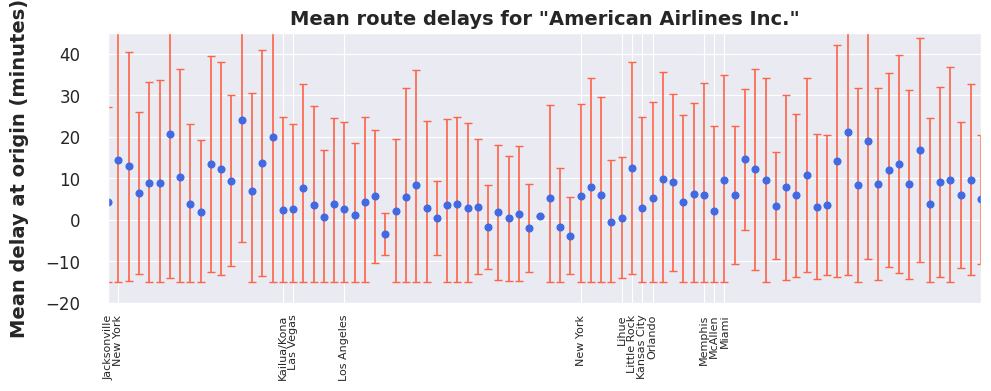

In [ ]:
mean_val = [] ; std_val = [] ; x_label = []

i = 0
for route, liste_retards in liste_trajet:

    index = route.split('-')[0]
    x_label.append(identify_airport[index])

    trajet2 = [min(90, s) for s in liste_retards]

    mean_val.append(np.mean(trajet2))
    std_val.append(np.std(trajet2))
    i += 1

fig, ax = plt.subplots(figsize=(10,4))

std_min = [ min(15 + mean_val[i], s) for i,s in enumerate(std_val)]

ax.errorbar(list(range(i)), mean_val, yerr = [std_min, std_val], fmt='o',
            ecolor='tomato', mfc='royalblue', mec='royalblue', capsize=3)

ax.set_title('Mean route delays for "{}"'.format(abbr_companies[carrier]),
              fontsize=14, weight = 'bold')
plt.ylabel('Mean delay at origin (minutes)', fontsize=14, weight = 'bold', labelpad=12)

imin, imax = 145, 230
plt.xlim(imin, imax) ; plt.ylim(-20, 45)

liste_ticks = [imin]
for j in range(imin+1, imax):
    if x_label[j] == x_label[j-1]: continue
    liste_ticks.append(j)

ax.set_xticks(liste_ticks)
ax.set_xticklabels([x_label[int(x)] for x in ax.get_xticks()], rotation = 90, fontsize = 8)
plt.setp(ax.get_yticklabels(), fontsize=12, rotation = 0)
ax.tick_params(axis='y', which='major', pad=15)

plt.tight_layout()
plt.show()

Biểu đồ này thể hiện độ trễ trung bình của hãng American Airlines dựa trên thành phố xuất phát và điểm đến (lưu ý rằng trên trục hoành, chỉ có tên thành phố xuất phát được hiển thị để đảm bảo tính rõ ràng). Các thanh sai số (error bars) đi kèm với từng chặng bay tương ứng với độ lệch chuẩn của chặng đó.

Trong ví dụ này, có thể thấy rằng đối với một sân bay xuất phát nhất định, độ trễ sẽ biến động tùy thuộc vào điểm đến. Chẳng hạn, sự thay đổi lớn nhất được ghi nhận tại New York hoặc Miami, nơi độ trễ trung bình dao động trong khoảng từ 0 đến ~20 phút tùy theo chặng bay cụ thể.

___
### 5. Sự biến thiên của độ trễ theo thời gian (Temporal variability of delays)
Trong phần này, nhóm sẽ xem xét cách thức độ trễ thay đổi theo các mốc thời gian khác nhau. Khi xét trường hợp của một hãng hàng không và một sân bay cụ thể, các khoảng trễ có thể được biểu diễn một cách trực quan theo ngày và giờ.

(Lưu ý: Trước khi thực hiện việc này, nhóm sẽ định nghĩa một Class Python. Class này sẽ được sử dụng xuyên suốt trong các phần tiếp theo để chuẩn hóa việc trích xuất dữ liệu và vẽ biểu đồ một cách chuyên nghiệp):

In [ ]:
class Figure_style():
    def __init__(self, size_x = 11, size_y = 5, nrows = 1, ncols = 1):
        sns.set_style("white")
        sns.set_context("notebook", font_scale=1.2, rc={"lines.linewidth": 2.5})
        self.fig, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize=(size_x,size_y,))
        # convert self.axs to 2D array
        if nrows == 1 and ncols == 1:
            self.axs = np.reshape(axs, (1, -1))
        elif nrows == 1:
            self.axs = np.reshape(axs, (1, -1))
        elif ncols == 1:
            self.axs = np.reshape(axs, (-1, 1))

    def pos_update(self, ix, iy):
        self.ix, self.iy = ix, iy

    def style(self):
        self.axs[self.ix, self.iy].spines['right'].set_visible(False)
        self.axs[self.ix, self.iy].spines['top'].set_visible(False)
        self.axs[self.ix, self.iy].yaxis.grid(color='lightgray', linestyle=':')
        self.axs[self.ix, self.iy].xaxis.grid(color='lightgray', linestyle=':')
        self.axs[self.ix, self.iy].tick_params(axis='both', which='major',
                                               labelsize=10, size = 5)

    def draw_legend(self, location='upper right'):
        legend = self.axs[self.ix, self.iy].legend(loc = location, shadow=True,
                                        facecolor = 'g', frameon = True)
        legend.get_frame().set_facecolor('whitesmoke')

    def cust_plot(self, x, y, color='b', linestyle='-', linewidth=1, marker=None, label=''):
        if marker:
            markerfacecolor, marker, markersize = marker[:]
            self.axs[self.ix, self.iy].plot(x, y, color = color, linestyle = linestyle,
                                linewidth = linewidth, marker = marker, label = label,
                                markerfacecolor = markerfacecolor, markersize = markersize)
        else:
            self.axs[self.ix, self.iy].plot(x, y, color = color, linestyle = linestyle,
                                        linewidth = linewidth, label=label)
        self.fig.autofmt_xdate()

    def cust_plot_date(self, x, y, color='lightblue', linestyle='-',
                       linewidth=1, markeredge=False, label=''):
        markeredgewidth = 1 if markeredge else 0
        self.axs[self.ix, self.iy].plot_date(x, y, color='lightblue', markeredgecolor='grey',
                                  markeredgewidth = markeredgewidth, label=label)

    def cust_scatter(self, x, y, color = 'lightblue', markeredge = False, label=''):
        markeredgewidth = 1 if markeredge else 0
        self.axs[self.ix, self.iy].scatter(x, y, color=color,  edgecolor='grey',
                                  linewidths = markeredgewidth, label=label)

    def set_xlabel(self, label, fontsize = 14):
        self.axs[self.ix, self.iy].set_xlabel(label, fontsize = fontsize)

    def set_ylabel(self, label, fontsize = 14):
        self.axs[self.ix, self.iy].set_ylabel(label, fontsize = fontsize)

    def set_xlim(self, lim_inf, lim_sup):
        self.axs[self.ix, self.iy].set_xlim([lim_inf, lim_sup])

    def set_ylim(self, lim_inf, lim_sup):
        self.axs[self.ix, self.iy].set_ylim([lim_inf, lim_sup])

In [ ]:
carrier = 'WN'
id_airport = 4
liste_origin_airport = df[df['AIRLINE'] == carrier]['ORIGIN_AIRPORT'].unique()
df2 = df[(df['AIRLINE'] == carrier) & (df['ARRIVAL_DELAY'] > 0)
          & (df['ORIGIN_AIRPORT'] == liste_origin_airport[id_airport])]
df2.sort_values('SCHEDULED_DEPARTURE', inplace = True)

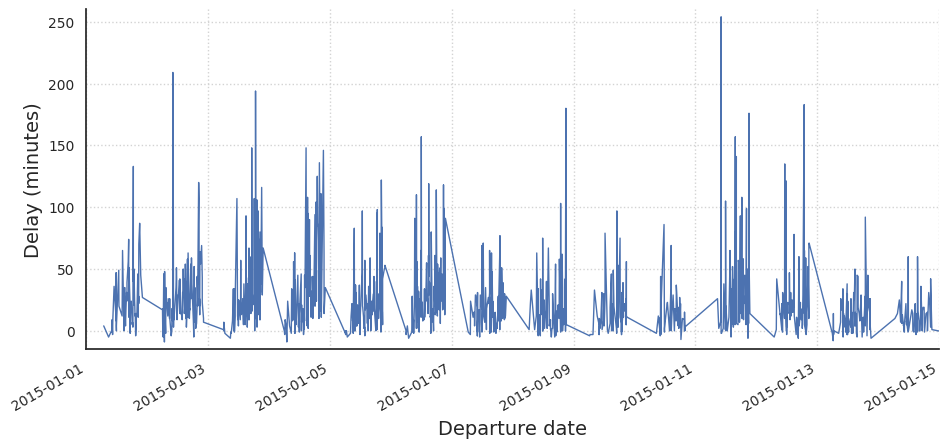

In [ ]:
fig1 = Figure_style(11, 5, 1, 1)
fig1.pos_update(0, 0)

fig1.cust_plot(df2['SCHEDULED_DEPARTURE'], df2['DEPARTURE_DELAY'], linestyle='-')
fig1.style()

fig1.set_ylabel('Delay (minutes)', fontsize = 14)
fig1.set_xlabel('Departure date', fontsize = 14)

date_1 = datetime.datetime(2015,1,1)
date_2 = datetime.datetime(2015,1,15)
fig1.set_xlim(date_1, date_2)
fig1.set_ylim(-15, 260)

plt.show();

Biểu đồ này cho thấy sự tồn tại của các chu kỳ, không chỉ về tần suất mà còn về mức độ (magnitude) của các khoảng trễ chuyến. Trên thực tế, việc quan sát thấy những chu kỳ này là hoàn toàn hợp lý theo trực giác, bởi chúng là hệ quả của quy luật luân phiên ngày-đêm và thực tế là các hoạt động tại sân bay sẽ giảm thiểu đáng kể (hoặc gần như dừng hẳn) vào ban đêm.

Điều này gợi ý rằng thời điểm cất cánh (take-off time) sẽ là một biến số quan trọng trong việc xây dựng mô hình dự báo độ trễ. Để kiểm chứng giả thuyết này, nhóm sẽ xem xét sự biến thiên của độ trễ trung bình dựa theo thời gian khởi hành, bằng cách tổng hợp dữ liệu của toàn bộ tháng hiện tại:

In [ ]:
def func2(x, a, b, c):
    return a * x**2 +  b*x + c

df2['heure_depart'] =  df2['SCHEDULED_DEPARTURE'].apply(lambda x:x.time())
test2 = df2['DEPARTURE_DELAY'].groupby(df2['heure_depart']).apply(get_stats).unstack()
fct = lambda x:x.hour*3600+x.minute*60+x.second
x_val = np.array([fct(s) for s in test2.index])
y_val = test2['mean']
popt, pcov = curve_fit(func2, x_val, y_val, p0 = [1, 2, 3])
test2['fit'] = pd.Series(func2(x_val, *popt), index = test2.index)

điều này trực quan hiển thị:

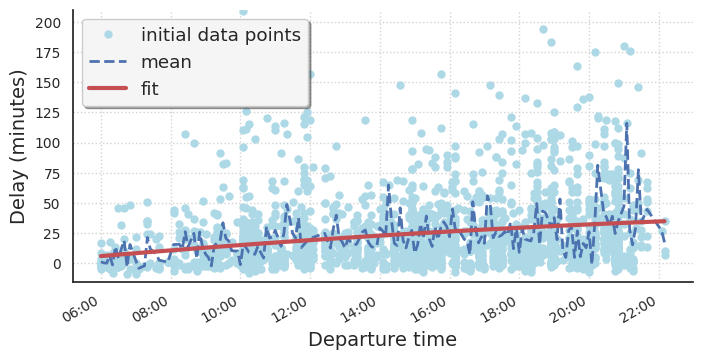

In [ ]:
import datetime
import matplotlib.dates as mdates

# 1. CHUẨN BỊ DỮ LIỆU
base_date = datetime.date(2015, 1, 1)

# Chuyển đổi df2['heure_depart'] thành datetime hoàn chỉnh
df2['heure_depart_dt'] = df2['heure_depart'].apply(lambda x: datetime.datetime.combine(base_date, x))

# Chuyển đổi Index của test2 thành datetime hoàn chỉnh
test2.index = [datetime.datetime.combine(base_date, t) for t in test2.index]

# 2. VẼ BIỂU ĐỒ
fig1 = Figure_style(8, 4, 1, 1)
fig1.pos_update(0, 0)

# Lưu ý: Dùng cột 'heure_depart_dt' mới tạo ở bước trên
fig1.cust_plot_date(df2['heure_depart_dt'], df2['DEPARTURE_DELAY'],
                    markeredge=False, label='initial data points')

fig1.cust_plot(test2.index, test2['mean'], linestyle='--', linewidth=2, label='mean')
fig1.cust_plot(test2.index, test2['fit'], color='r', linestyle='-', linewidth=3, label='fit')

fig1.style()
fig1.draw_legend('upper left')

fig1.axs[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

fig1.set_ylabel('Delay (minutes)', fontsize = 14)
fig1.set_xlabel('Departure time', fontsize = 14)
fig1.set_ylim(-15, 210)

plt.show()

Qua đây, chúng ta có thể thấy rằng độ trễ trung bình có xu hướng tăng dần theo thời gian khởi hành trong ngày: các chuyến bay thường khởi hành đúng giờ vào sáng sớm, và độ trễ tăng dần một cách gần như đơn điệu (tăng đều) lên đến khoảng 30 phút vào thời điểm cuối ngày. Trên thực tế, quy luật này mang tính phổ quát; nếu xem xét các sân bay hoặc hãng hàng không khác, chúng ta cũng sẽ tìm thấy những xu hướng tương tự.
___
### 6. Dự đoán độ trễ chuyến bay (Predicting flight delays)
Các phần trước đã tập trung vào việc khám phá và phân tích tập dữ liệu (EDA). Ở chương này, nhóm sẽ bắt đầu thực hiện việc xây dựng mô hình dự báo độ trễ chuyến bay.Mục tiêu của phần này là tạo ra một mô hình sử dụng "cửa sổ dữ liệu" (data window) trong 3 tuần để dự đoán độ trễ cho tuần kế tiếp. Cụ thể, nhóm quyết định sử dụng dữ liệu của tháng 1 với mục đích dự báo các khoảng trễ trong giai đoạn từ ngày $23$ đến ngày $31$ tháng $1$.

In [ ]:
df_train = df[df['SCHEDULED_DEPARTURE'].apply(lambda x:x.date()) < datetime.date(2015, 1, 23)]
df_test  = df[df['SCHEDULED_DEPARTURE'].apply(lambda x:x.date()) > datetime.date(2015, 1, 23)]
df = df_train

___
### 6.1 Mô hình số 1: Một hãng hàng không, một sân bay (Model nº1: one airline, one airport)
Trước hết, nhóm quyết định mô hình hóa các khoảng trễ bằng cách xem xét riêng biệt từng hãng hàng không và phân tách dữ liệu theo các sân bay xuất phát khác nhau. Mô hình đầu tiên này có thể được coi là một "mô hình thử nghiệm" (toy-model), giúp nhận diện sớm các vấn đề có thể phát sinh trong giai đoạn triển khai thực tế (production). Khi xử lý toàn bộ tập dữ liệu, số lượng các phép khớp hàm (fits) sẽ cực kỳ lớn; do đó, chúng ta cần đảm bảo quy trình tự động hóa đủ mạnh mẽ (robust) để duy trì chất lượng cho các kết quả đầu ra.

#### 6.1.1 Những sai sót thường gặp (Pitfalls)
**a) Thiếu hụt dữ liệu thống kê (Unsufficient statistics)**

Trước tiên, nhóm xem xét các chuyến bay của hãng American Airlines và thực hiện thống kê số lượng chuyến bay cất cánh từ mỗi sân bay:

In [ ]:
carrier = 'AA'
check_airports = df[(df['AIRLINE'] == carrier)]['DEPARTURE_DELAY'].groupby(
                         df['ORIGIN_AIRPORT']).apply(get_stats).unstack()
check_airports.sort_values('count', ascending = False, inplace = True)
check_airports[-5:]

,min,max,count,mean
ORIGIN_AIRPORT,,,,
JAC,-19.0,47.0,25.0,-3.640000
GUC,-24.0,199.0,22.0,13.227273
SDF,-8.0,55.0,19.0,8.421053
LIT,-5.0,74.0,9.0,12.555556
MTJ,-2.0,51.0,3.0,26.000000


Nhìn vào danh sách này, chúng ta có thể thấy rằng các sân bay ít được ghé thăm nhất chỉ có vài chuyến bay trong một tháng. Do đó, trong trường hợp xấu nhất, chúng ta hoàn toàn không thể thực hiện phép hồi quy (regression) cho các địa điểm này.

**b) Độ trễ cực đoan (Extreme delays)**

Một "cạm bẫy" khác cần tránh là các khoảng trễ mang tính "ngẫu nhiên" (accidental delays): chúng ta cần đặc biệt chú ý đến các khoảng trễ cực đoan (extreme delays). Thật vậy, trong quá trình khám phá dữ liệu (EDA), nhóm đã nhận thấy rằng thỉnh thoảng có những chuyến bay trễ tới vài giờ, thậm chí hàng chục giờ.

Tuy nhiên, loại trễ này chỉ là thiểu số (chiếm vài %) và nguyên nhân thường liên quan đến các sự kiện không thể dự báo trước (thời tiết xấu, hỏng hóc kỹ thuật, tai nạn...). Việc đưa các giá trị cực đoan này vào phân tích sẽ dễ gây ra sự sai lệch (bias) cho kết quả. Hơn nữa, trọng số của các giá trị lớn này sẽ trở nên cực kỳ đáng kể nếu tập mẫu thống kê của chúng ta quá nhỏ.

Để minh họa cho điều này, trước tiên nhóm định nghĩa một hàm để tính toán độ trễ trung bình theo từng hãng hàng không và từng sân bay:

In [ ]:
def get_flight_delays(df, carrier, id_airport, extrem_values = False):
    df2 = df[(df['AIRLINE'] == carrier) & (df['ORIGIN_AIRPORT'] == id_airport)]
    # remove extreme values before fitting
    if extrem_values:
        df2['DEPARTURE_DELAY'] = df2['DEPARTURE_DELAY'].apply(lambda x:x if x < 60 else np.nan)
        df2.dropna(how = 'any')
    # Conversion: date + heure -> heure
    df2.sort_values('SCHEDULED_DEPARTURE', inplace = True)
    df2['heure_depart'] =  df2['SCHEDULED_DEPARTURE'].apply(lambda x:x.time())
    # regroupement des vols par heure de départ et calcul de la moyenne
    test2 = df2['DEPARTURE_DELAY'].groupby(df2['heure_depart']).apply(get_stats).unstack()
    test2.reset_index(inplace=True)
    # conversion de l'heure en secondes
    fct = lambda x:x.hour*3600+x.minute*60+x.second
    test2.reset_index(inplace=True)
    test2['heure_depart_min'] = test2['heure_depart'].apply(fct)
    return test2

---
Và sau đó là một hàm thực hiện phép hồi quy tuyến tính (linear regression) dựa trên các giá trị này:

In [ ]:
def linear_regression(test2):
    test = test2[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)
    X = np.array(test['heure_depart_min'])
    Y = np.array(test['mean'])
    X = X.reshape(len(X),1)
    Y = Y.reshape(len(Y),1)
    regr = linear_model.LinearRegression()
    regr.fit(X, Y)
    result = regr.predict(X)
    return X, Y, result

Tiếp theo, nhóm xem xét hai kịch bản khác nhau. Trong trường hợp thứ nhất, nhóm giữ lại toàn bộ các giá trị dữ liệu ban đầu. Ở trường hợp thứ hai, nhóm tiến hành loại bỏ tất cả các khoảng trễ lớn hơn $1$ giờ trước khi tính toán độ trễ trung bình. Kết quả đối sánh giữa hai trường hợp này cho thấy sự khác biệt rất rõ rệt:

In [ ]:
id_airport = 'PHL'
df2 = df[(df['AIRLINE'] == carrier) & (df['ORIGIN_AIRPORT'] == id_airport)]
df2['heure_depart'] =  df2['SCHEDULED_DEPARTURE'].apply(lambda x:x.time())
df2['heure_depart'] = df2['heure_depart'].apply(lambda x:x.hour*3600+x.minute*60+x.second)
# first case
test2 = get_flight_delays(df, carrier, id_airport, False)
X1, Y1, result2 = linear_regression(test2)
# second case
test3 = get_flight_delays(df, carrier, id_airport, True)
X2, Y2, result3 = linear_regression(test3)

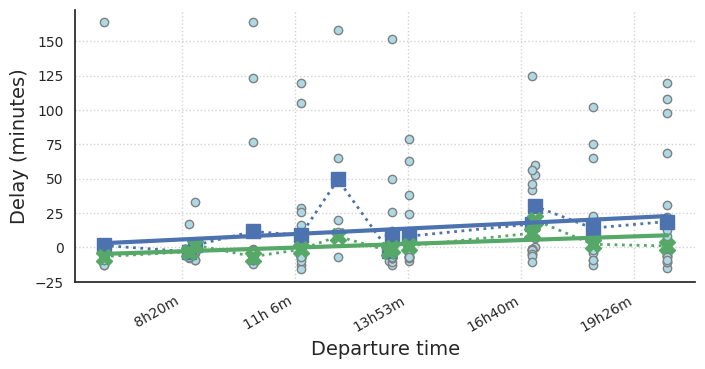

In [ ]:
fig1 = Figure_style(8, 4, 1, 1)
fig1.pos_update(0, 0)
fig1.cust_scatter(df2['heure_depart'], df2['DEPARTURE_DELAY'], markeredge = True)
fig1.cust_plot(X1, Y1, color = 'b', linestyle = ':', linewidth = 2, marker = ('b','s', 10))
fig1.cust_plot(X2, Y2, color = 'g', linestyle = ':', linewidth = 2, marker = ('g','X', 12))
fig1.cust_plot(X1, result2, color = 'b', linewidth = 3)
fig1.cust_plot(X2, result3, color = 'g', linewidth = 3)
fig1.style()
fig1.set_ylabel('Delay (minutes)', fontsize = 14)
fig1.set_xlabel('Departure time', fontsize = 14)
# convert and set the x ticks labels
fct_convert = lambda x: (int(x/3600) , int(divmod(x,3600)[1]/60))
fig1.axs[fig1.ix, fig1.iy].set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*fct_convert(x))
                                            for x in fig1.axs[fig1.ix, fig1.iy].get_xticks()]);
plt.show();

Trước hết, trong biểu đồ này, các điểm màu xám đại diện cho từng chuyến bay riêng lẻ. Giá trị trung bình của các điểm này cho ta độ trễ trung bình, trong đó giá trị trung bình của tập hợp các điểm dữ liệu ban đầu tương ứng với các ô vuông màu xanh dương. Bằng cách loại bỏ các khoảng trễ cực đoan (> 1 giờ), chúng ta thu được các giá trị độ trễ trung bình mới, được biểu diễn bằng các dấu thập màu xanh lá cây.

Như vậy, trong trường hợp đầu tiên, đường hồi quy (đường nét liền màu xanh dương) đưa ra dự báo về độ trễ trung bình cao hơn khoảng $\sim$ 10 phút so với dự báo thu được ở trường hợp thứ hai (đường màu xanh lá cây), và sự chênh lệch này xuất hiện ở mọi khung giờ trong ngày.

**Kết luận:** Qua ví dụ này, chúng ta thấy rằng cách thức xử lý các khoảng trễ cực đoan sẽ có tác động quan trọng đến việc xây dựng mô hình dự báo. Tuy nhiên, cần lưu ý rằng ví dụ này là một trường hợp điển hình được lựa chọn (chosen case) để làm nổi bật tác động của các giá trị cực đoan khi số lượng chuyến bay còn hạn chế. Có thể dự đoán rằng tác động của những khoảng trễ như vậy sẽ ít rõ rệt hơn trong đa số các trường hợp còn lại (khi kích thước mẫu lớn hơn).

___
### 5.1.2 Bậc của đa thức: Chia tập dữ liệu (Polynomial degree: splitting the dataset)

Trong thực tế, thay vì chỉ thực hiện hồi quy tuyến tính đơn giản, chúng ta có thể cải thiện mô hình bằng cách khớp dữ liệu với một đa thức bậc $N$. Khi đó, việc xác định bậc $N$ tối ưu để biểu diễn dữ liệu là rất cần thiết. Tuy nhiên, khi tăng bậc của đa thức, việc ngăn chặn hiện tượng quá khớp (over-fitting) là cực kỳ quan trọng; chúng ta thực hiện điều này bằng cách chia tập dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set).

Một vấn đề có thể phát sinh với quy trình này là mô hình có thể kết thúc bằng việc học gián tiếp các nội dung của tập kiểm tra, dẫn đến kết quả bị sai lệch (biased). Để tránh tình trạng này, dữ liệu có thể được chia làm 3 phần: huấn luyện (train), kiểm tra (test) và thẩm định (validation). Một giải pháp thay thế thường mạnh mẽ (robust) hơn là phương pháp kiểm chứng chéo (cross-validation). Phương pháp này bắt đầu bằng việc chia dữ liệu thành tập huấn luyện và tập kiểm tra. Việc học vẫn diễn ra trên tập huấn luyện, nhưng để tránh học quá mức (over-learning), tập huấn luyện này lại được chia nhỏ thành nhiều phần để luân phiên dùng cho việc huấn luyện và kiểm tra nội bộ.

Cần lưu ý rằng nếu tập dữ liệu nhỏ, việc chia tập train/test có thể gây ra sai lệch trong việc ước tính các tham số. Trong thực tế, phương pháp cross-validation giúp tránh được sai lệch này. Mô hình hiện tại của chúng ta sẽ gặp phải vấn đề đó, và trong phần tiếp theo, nhóm sẽ làm rõ điểm này. Ví dụ, hãy xét một trường hợp cực đoan: sau khi chia dữ liệu, tập huấn luyện chỉ chứa các chuyến bay trước 20 giờ, còn tập kiểm tra lại chỉ chứa các chuyến bay sau 20 giờ. Khi đó, mô hình sẽ không thể tái hiện chính xác dữ liệu kiểm tra vì nó chưa từng thấy dữ liệu tương đương trong lúc huấn luyện. Phương pháp kiểm chứng chéo sẽ giúp tránh lỗi này vì mọi dữ liệu đều được sử dụng luân phiên để dẫn dắt mô hình.

**a) Thiên kiến gây ra bởi việc phân chia tập dữ liệu (Bias introduced by the separation of the data set)**

Để kiểm tra tác động của việc chia dữ liệu đối với việc xác định mô hình, trước tiên nhóm định nghĩa class fit_polynome:

In [ ]:
import numpy as np
import random

class fit_polynome:

    def __init__(self, data):
        self.data = data[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)

    def split(self, method):
        self.method = method
        self.X = np.array(self.data['heure_depart_min'])
        self.Y = np.array(self.data['mean'])
        self.X = self.X.reshape(len(self.X),1)
        self.Y = self.Y.reshape(len(self.Y),1)

        if method == 'all':
            self.X_train = self.X
            self.Y_train = self.Y
            self.X_test  = self.X
            self.Y_test  = self.Y
        elif method == 'split':
            self.X_train, self.X_test, self.Y_train, self.Y_test = \
                train_test_split(self.X, self.Y, test_size=0.3)

    def train(self, pol_order):
        self.poly = PolynomialFeatures(degree = pol_order)
        self.regr = linear_model.LinearRegression()
        self.X_ = self.poly.fit_transform(self.X_train)
        self.regr.fit(self.X_, self.Y_train)

    def predict(self, X):
        self.X_ = self.poly.fit_transform(X)
        self.result = self.regr.predict(self.X_)

    def calc_score(self):
        X_ = self.poly.fit_transform(self.X_test)
        result = self.regr.predict(X_)
        self.score = metrics.mean_squared_error(result, self.Y_test)

Lớp `fit_polynome` cho phép thực hiện tất cả các thao tác liên quan đến việc khớp mô hình (fitting) và lưu trữ các kết quả thu được. Khi gọi phương thức `split()`, biến `'method'` sẽ xác định cách thức phân tách dữ liệu ban đầu:
- `method = 'all'`: Toàn bộ dữ liệu đầu vào được sử dụng để huấn luyện, sau đó dùng chính dữ liệu đó để kiểm tra mô hình.
- `method = 'split'`: Sử dụng phương thức `train_test_split()` của thư viện `sklearn` để chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set).

Tiếp theo, các phương thức khác của lớp đảm nhận các chức năng sau:
- `train(n)`: Thực hiện huấn luyện dữ liệu trên tập huấn luyện bằng một đa thức bậc $n$.
- `predict(X)`: Tính toán các giá trị đầu ra $Y$ tương ứng với đầu vào $X$ dựa trên mô hình đã được huấn luyện trước đó.
- `calc_score()`: Tính toán điểm số (score/accuracy) của mô hình dựa trên dữ liệu của tập kiểm tra.

Để minh họa cho thiên kiến (bias) phát sinh do việc lựa chọn tập kiểm tra, nhóm tiến hành theo cách sau: thực hiện việc chia tập "huấn luyện / kiểm tra" ngẫu nhiên nhiều lần trên cùng một tập dữ liệu; với mỗi lần chia, nhóm sẽ khớp các đa thức bậc $n = 1, 2$ và $3$, đồng thời tính toán điểm số tương ứng của chúng. Kết quả sẽ cho thấy rằng: tùy thuộc vào cách chia dữ liệu mà điểm số tốt nhất có thể rơi vào bất kỳ giá trị $n$ nào.

Trong thực tế, chỉ cần thực hiện khoảng mười lần mô hình hóa là có thể quan sát được kết quả này. Sự sai lệch này bắt nguồn từ chính việc lựa chọn cách chia "train / test" và do kích thước tập dữ liệu cần mô hình hóa còn nhỏ. Để minh họa cụ thể, nhóm lấy ví dụ trường hợp của hãng hàng không American Airlines (hãng lớn thứ hai) tại sân bay có ID 1129804 – nơi có lưu lượng chuyến bay cao nhất của hãng này. Đây vốn là một trong những kịch bản ít có khả năng xảy ra loại thiên kiến này nhất, nhưng trên thực tế, nó vẫn xuất hiện:

model n1 , min. pour n = 1, score = 235.1
model n2 , min. pour n = 2, score = 93.1
model n3 , min. pour n = 3, score = 9.9


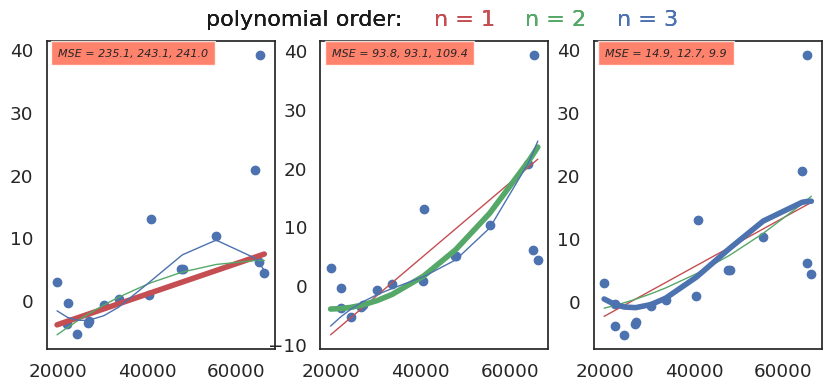

In [ ]:
fig = plt.figure(1, figsize=(10,4))

ax = ['_' for _ in range(4)]
ax[1]=fig.add_subplot(131)
ax[2]=fig.add_subplot(132)
ax[3]=fig.add_subplot(133)

id_airport = 'BNA'
test2 = get_flight_delays(df, carrier, id_airport, True)

result = ['_' for _ in range(4)]
score = [10000 for _ in range(4)]
found = [False for _ in range(4)]
fit = fit_polynome(test2)

color = '.rgbyc'

inc = 0
while True:
    inc += 1
    fit.split('split')
    for i in range(1,4):
        fit.train(pol_order = i)
        fit.predict(fit.X)
        result[i] = fit.result
        fit.calc_score()
        score[i]  = fit.score

    [ind_min] = [j for j,val in enumerate(score) if min(score) == val]
    print("model n{:<2}, min. pour n = {}, score = {:.1f}".format(inc, ind_min,score[ind_min]))

    if not found[ind_min]:
        for i in range(1,4):
            ax[ind_min].plot(fit.X, result[i], color[i], linewidth = 4 if i == ind_min else 1)
        ax[ind_min].scatter(fit.X, fit.Y)
        ax[ind_min].text(0.05, 0.95, 'MSE = {:.1f}, {:.1f}, {:.1f}'.format(*score[1:4]),
                         style='italic', transform=ax[ind_min].transAxes, fontsize = 8,
                         bbox={'facecolor':'tomato', 'alpha':0.8, 'pad':5})
        found[ind_min] = True

    shift = 0.5
    plt.text(-1+shift, 1.05, "polynomial order:", color = 'k',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')
    plt.text(0+shift, 1.05, "n = 1", color = 'r',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')
    plt.text(0.4+shift, 1.05, "n = 2", color = 'g',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')
    plt.text(0.8+shift, 1.05, "n = 3", color = 'b',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')

    if inc == 40 or all(found[1:4]): break
plt.show()

Trong biểu đồ này, các khung hình từ trái sang phải tương ứng với 3 lần phân tách dữ liệu thành tập huấn luyện (train) và tập kiểm tra (test) khác nhau. Kết quả cho thấy các mô hình tốt nhất thu được lần lượt là các đa thức bậc $n=1, 2$ và $3$. Trên mỗi khung hình, cả 3 đường đa thức khớp dữ liệu đều được biểu diễn, trong đó mô hình tối ưu nhất được thể hiện bằng đường kẻ đậm.

**b) Lựa chọn bằng phương pháp kiểm chứng chéo (Selection by cross-validation)**

Một trong những ưu điểm lớn nhất của phương pháp kiểm chứng chéo (cross-validation) là giúp loại bỏ thiên kiến (bias) vừa nêu trên trong việc lựa chọn bậc của đa thức. Để áp dụng phương pháp này, nhóm định nghĩa một lớp (class) mới nhằm thực hiện các phép khớp mô hình một cách chuẩn xác hơn:

In [ ]:
class fit_polynome_cv:

    def __init__(self, data):
        self.data = data[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)
        self.X = np.array(self.data['heure_depart_min'])
        self.Y = np.array(self.data['mean'])
        self.X = self.X.reshape(len(self.X),1)
        self.Y = self.Y.reshape(len(self.Y),1)

    def train(self, pol_order, nb_folds):
        self.poly = PolynomialFeatures(degree = pol_order)
        self.regr = linear_model.LinearRegression()
        self.X_ = self.poly.fit_transform(self.X)
        self.result = cross_val_predict(self.regr, self.X_, self.Y, cv = nb_folds)

    def calc_score(self, pol_order, nb_folds):
        self.poly = PolynomialFeatures(degree = pol_order)
        self.regr = linear_model.LinearRegression()
        self.X_ = self.poly.fit_transform(self.X)
        self.score = np.mean(cross_val_score(self.regr, self.X_, self.Y,
                                             cv = nb_folds, scoring = 'neg_mean_squared_error'))

Lớp (class) này bao gồm hai phương thức chính:
- `train(n, nb_folds)`: Xác định số lượng tập huấn luyện (`nb_folds`) từ tập dữ liệu ban đầu và thực hiện khớp đa thức bậc $n$ trên mỗi tập này. Phương thức này sẽ trả về kết quả là các giá trị dự báo $Y$ thu được từ các tập kiểm tra khác nhau.
- `calc_score(n, nb_folds)`: Thực hiện quy trình tương tự như phương thức train, nhưng thay vì trả về các giá trị dự báo, phương thức này sẽ tính toán điểm số (score) của phép khớp trên các tập dữ liệu kiểm tra khác nhau.

Theo mặc định, phương pháp 'K-fold' được sử dụng bởi các hàm `cross_val_predict()` và `cross_val_score()` trong thư viện `sklearn`. Các hàm này có tính tất định (deterministic) trong việc lựa chọn các phần chia ($K$ folds), điều này đồng nghĩa với việc với một giá trị $K$ cố định, kết quả thu được sẽ luôn nhất quán. Như đã thấy ở ví dụ trước, điều này không xảy ra khi sử dụng phương thức `train_test_split()` (vốn có tính ngẫu nhiên). Do đó, nếu áp dụng trên cùng một tập dữ liệu như ví dụ trước, phương pháp kiểm chứng chéo (cross-validation) sẽ giúp chúng ta lựa chọn được bậc đa thức tối ưu nhất một cách đáng tin cậy:

In [ ]:
#id_airport = 1129804
nb_folds = 10
print('Max possible number of folds: {} \n'.format(test2.shape[0]-1))
fit2 = fit_polynome_cv(test2)
for i in range(1, 8):
    fit2.calc_score(i, nb_folds)
    print('n={} -> MSE = {}'.format(i, round(abs(fit2.score),3)))

Max possible number of folds: 16 

n=1 -> MSE = 130.629
n=2 -> MSE = 151.79
n=3 -> MSE = 159.456
n=4 -> MSE = 162.631
n=5 -> MSE = 166.966
n=6 -> MSE = 173.08
n=7 -> MSE = 181.361


Có thể thấy rằng việc sử dụng phương pháp này đã chỉ ra mô hình tối ưu nhất (nghĩa là mô hình có khả năng tổng quát hóa tốt nhất) đạt được khi sử dụng đa thức bậc 2. Đến giai đoạn này của quy trình, việc lựa chọn bậc đa thức đã được kiểm chứng thành công, và giờ đây nhóm có thể sử dụng toàn bộ tập dữ liệu để tiến hành khớp (fit) mô hình:

In [ ]:
fit = fit_polynome(test2)
fit.split('all')
fit.train(pol_order = 2)
fit.predict(fit.X)

Như vậy, trong biểu đồ dưới đây, việc kết hợp $50$ đường đa thức khớp dữ liệu ($K = 50$ polynomial fits) từ quy trình kiểm chứng chéo đã tạo nên đường màu đỏ. Trong khi đó, đường khớp đa thức tương ứng với mô hình hoàn thiện cuối cùng được thể hiện bằng đường màu xanh dương.

In [ ]:
fit2.train(pol_order = 2, nb_folds = nb_folds)

In [ ]:
fig1 = Figure_style(8, 4, 1, 1) ; fig1.pos_update(0, 0)
fig1.cust_scatter(fit2.X, fit2.Y, markeredge = True, label = 'initial data points')
fig1.cust_plot(fit.X,fit2.result,color=u'#1f77b4',linestyle='--',linewidth=2,label='CV output')
fig1.cust_plot(fit.X,fit.result,color=u'#ff7f0e',linewidth = 3,label='final fit')
fig1.style(); fig1.draw_legend('upper left')
fig1.set_ylabel('Delay (minutes)') ; fig1.set_xlabel('Departure time')
#____________________________________
# convert and set the x ticks labels
fct_convert = lambda x: (int(x/3600) , int(divmod(x,3600)[1]/60))
fig1.axs[fig1.ix, fig1.iy].set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*fct_convert(x))
                                            for x in fig1.axs[fig1.ix, fig1.iy].get_xticks()]);

In [ ]:
score = metrics.mean_squared_error(fit.result, fit2.Y)
score

56.862847718920975

#### 6.1.3 Kiểm thử mô hình: Dự báo độ trễ vào cuối tháng Một (Model test: prediction of end-January delays)

Ở giai đoạn này, mô hình sau khi được huấn luyện sẽ được kiểm thử lại trên chính tập huấn luyện (bao gồm dữ liệu của 3 tuần đầu tháng Một). Tiếp theo, chúng ta sẽ tiến hành đối chiếu giữa các kết quả dự báo và dữ liệu quan sát thực tế trong tuần thứ tư của tháng Một:

In [ ]:
test_data = get_flight_delays(df_test, carrier, id_airport, True)
test_data = test_data[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)
X_test = np.array(test_data['heure_depart_min'])
Y_test = np.array(test_data['mean'])
X_test = X_test.reshape(len(X_test),1)
Y_test = Y_test.reshape(len(Y_test),1)
fit.predict(X_test)

Và chỉ số MSE (Sai số bình phương trung bình) của mô hình đạt mức:

In [ ]:
score = metrics.mean_squared_error(fit.result, Y_test)
score

108.67130851608417

Để có cái nhìn rõ nét hơn về ý nghĩa của giá trị MSE này, chúng ta có thể giả định một mức sai số không đổi tại mọi điểm trong tập dữ liệu. Trong trường hợp đó, tại mỗi điểm $i$, ta có phương trình:\begin{eqnarray}y_i - f(x_i) = cste = \sqrt{MSE}\end{eqnarray}

In [ ]:
'Ecart = {:.2f} min'.format(np.sqrt(score))

'Ecart = 10.42 min'

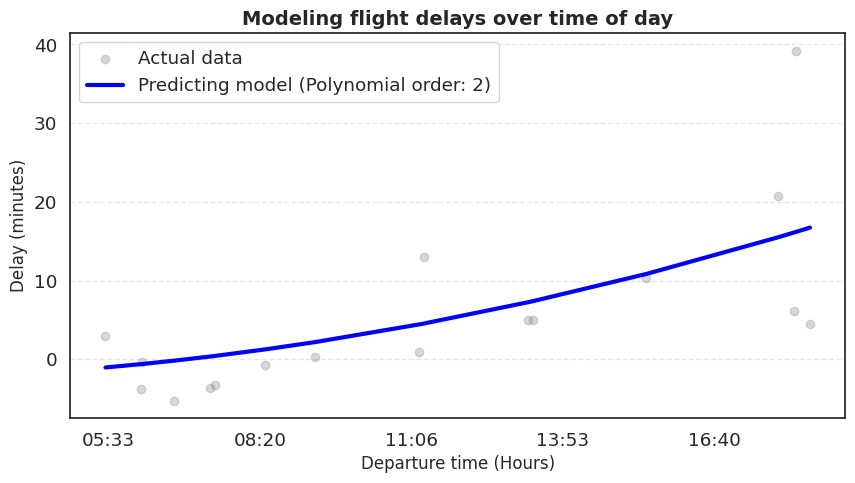

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Vẽ dữ liệu (Sử dụng trực tiếp các biến X, Y đang chứa số giây của bạn)
# LƯU Ý: Thay fit.X, fit.Y bằng đúng tên biến dữ liệu thô của nhóm.
# Thay result[2] bằng kết quả của mô hình bậc 2 (hoặc bậc tối ưu nhóm chọn)
ax.scatter(fit.X, fit.Y, alpha=0.3, color='gray', label='Actual data')
ax.plot(fit.X, result[2], color='blue', linewidth=3, label='Predicting model (Polynomial order: 2)')

# 3. ĐỊNH DẠNG TRỤC X TỪ GIÂY SANG GIỜ:PHÚT (HH:MM)
def format_time(x, pos):
    hours = int(x // 3600)
    minutes = int((x % 3600) // 60)
    # Xử lý để giờ hiển thị gọn gàng trong 24h
    hours = hours % 24
    return f"{hours:02d}:{minutes:02d}"

# Áp dụng bộ định dạng cho trục X
ax.xaxis.set_major_formatter(FuncFormatter(format_time))

# 4. Trang trí biểu đồ để đưa vào báo cáo
ax.set_ylabel('Delay (minutes)', fontsize=12)
ax.set_xlabel('Departure time (Hours)', fontsize=12)
ax.set_title('Modeling flight delays over time of day', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show();

In [ ]:
import joblib

# 1. Huấn luyện lại với bậc tối ưu (ví dụ n=2)
fit.train(pol_order=2)

# 2. Lưu cả bộ chuyển đổi và mô hình vào cùng 1 file
joblib.dump({'poly': fit.poly, 'regr': fit.regr}, 'flight_delay_model.pkl')

print("Đã lưu bộ mô hình thành công!")

Đã lưu bộ mô hình thành công!


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import datetime

# 1. Tải bộ mô hình đã lưu
model_components = joblib.load('/content/flight_delay_model.pkl')
poly = model_components['poly']
regr = model_components['regr']

# 2. Thiết kế giao diện Web
st.set_page_config(page_title="Dự báo trễ chuyến bay", page_icon="✈️", layout="centered")

st.title("✈️ Ứng dụng Dự báo Trễ Chuyến Bay")
st.markdown("Nhập thời gian cất cánh dự kiến để xem máy bay của bạn có khả năng bị trễ bao nhiêu phút.")

# 3. Form nhập liệu từ người dùng
col1, col2 = st.columns(2)
with col1:
    airline = st.selectbox("Chọn hãng hàng không:", ["American Airlines", "Delta Airlines", "United Airlines"])
with col2:
    airport = st.selectbox("Chọn sân bay khởi hành:", ["BNA (Nashville)", "ATL (Atlanta)", "JFK (New York)"])

departure_time = st.time_input("Thời gian khởi hành dự kiến:", datetime.time(8, 00))

# 4. Nút bấm Dự đoán
if st.button("🔍 Dự đoán độ trễ", use_container_width=True):
    total_seconds = departure_time.hour * 3600 + departure_time.minute * 60
    X_input = np.array([[total_seconds]])
    X_poly = poly.transform(X_input)
    predicted_delay = regr.predict(X_poly)

    delay_minutes = max(0, int(predicted_delay.flatten()[0]))

    st.divider()
    if delay_minutes <= 15:
        st.success(f"✅ Tuyệt vời! Chuyến bay dự kiến sẽ cất cánh đúng giờ hoặc chỉ trễ nhẹ khoảng **{delay_minutes} phút**.")
    elif delay_minutes <= 45:
        st.warning(f"⚠️ Lưu ý: Chuyến bay có khả năng bị trễ khoảng **{delay_minutes} phút**.")
    else:
        st.error(f"🚨 Cảnh báo: Chuyến bay có rủi ro trễ chuyến cao, dự kiến trễ khoảng **{delay_minutes} phút**!")

Overwriting app.py


In [ ]:
# Cài đặt thư viện hỗ trợ Ngrok
!pip install pyngrok -q
from pyngrok import ngrok

# 1. Dán Authtoken của bạn vào đây (Chỉ cần chạy 1 lần duy nhất)
!ngrok config add-authtoken 3B7PBpv9I6jCfkFbDfCA1OXH3fv_2vwzmks5zrC7KEyRVPjXF

# 2. Tạo đường hầm kết nối với cổng 8501 (mặc định của Streamlit)
public_url = ngrok.connect(8501)
print(f"CLICK VÀO LINK NÀY ĐỂ DEMO: {public_url}")

# 3. Chạy ứng dụng Streamlit
!streamlit run app.py

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
CLICK VÀO LINK NÀY ĐỂ DEMO: NgrokTunnel: "https://kaeden-uncrooked-unzealously.ngrok-free.dev" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.118.253.126:8501

  Stopping...
